# Visualização dos baselines supervisionados

Notebook **somente de leitura/visualização** — não treina nada. Lê os artefatos gerados por `scripts/train_supervised_{resnetse5,cnnpff,rnn}.py` e por `scripts/train_supervised_combined.py` (modelo treinado na união dos 6 datasets) e produz:

1. **Curvas de treino** (loss e acc) com média ± std das 4 seeds — incl. coluna do modelo combinado
2. **Avaliação in-distribution** (test_acc) por (encoder × dataset), média ± std das 4 seeds
3. **Transfer learning zero-shot** — matriz 7×6 source→target (combinado na 1ª linha), média ± std das 4 seeds
4. **Generalização do modelo combinado** — combinado vs especialista vs transfer single-source
5. **Comparação dos 3 cenários** — barras (pooled em todos encoders × seeds): baseline vs combinado vs transfer out-domain
6. **t-SNE dos encoders** (epoch 0 / last / best, seed 0) — incl. modelo combinado
7. **t-SNE de transfer learning** (best.ckpt, seed 0) — matriz 7×6 com o combinado na 1ª linha

Todas as células toleram ausência de logs/checkpoints — basta reexecutar quando novos resultados chegarem. Resultados de avaliação são cacheados em `results/supervised_eval_transfer.csv`.

## 1. Setup

In [2]:
import sys
from pathlib import Path

_p = Path.cwd()
PROJECT_ROOT = None
while _p != _p.parent:
    if (_p / "minerva").is_dir() and (_p / "scripts").is_dir():
        PROJECT_ROOT = _p
        break
    _p = _p.parent
if PROJECT_ROOT is None:
    raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")

for p in (PROJECT_ROOT, PROJECT_ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/miguel/fed-har


In [3]:
import warnings
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.manifold import TSNE

from common import (
    CHECKPOINTS_ROOT,
    LOGS_ROOT,
    DATASETS,
    COMBINED_DATASET_NAME,
    SEEDS,
    NUM_CLASSES,
    make_datamodule,
)
from supervised.train_resnetse5 import build_model as build_resnetse5
from supervised.train_cnnpff import build_model as build_cnnpff
from supervised.train_rnn import build_model as build_rnn

warnings.filterwarnings("ignore")
sns.set_context("notebook")

ENCODERS = ["resnetse5", "cnnpff", "rnn"]
ENCODER_PRETTY = {"resnetse5": "ResNet-SE-5", "cnnpff": "CNN-PFF", "rnn": "RNN (BiGRU)"}
BUILD_MODEL = {
    "resnetse5": build_resnetse5,
    "cnnpff": build_cnnpff,
    "rnn": build_rnn,
}
ACTIVITY_LABELS = {0: "Sit", 1: "Stand", 2: "Walk", 3: "Stair-up", 4: "Stair-down", 5: "Run"}

# Treino conjunto ("combinado"): um modelo generalista treinado na união dos 6
# datasets. Entra como uma *fonte* extra nas análises de transfer learning, mas
# os *alvos* de avaliação continuam sendo apenas os 6 datasets reais (o conjunto
# "combined" não é um alvo, então a tabela in-distribution não muda).
# O combinado vem SEMPRE primeiro na lista de fontes, para aparecer nas primeiras
# linhas dos heatmaps e das matrizes de t-SNE de transfer.
COMBINED = COMBINED_DATASET_NAME
COMBINED_PRETTY = "Combinado (todos)"
TRANSFER_SOURCES = [COMBINED] + DATASETS    # fontes (modelos treinados) — combinado primeiro
CURVE_DATASETS = DATASETS + [COMBINED]      # colunas das curvas de treino

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
TRANSFER_CACHE = RESULTS_DIR / "supervised_eval_transfer.csv"

print(f"Device:   {DEVICE}")
print(f"Encoders: {ENCODERS}")
print(f"Datasets: {DATASETS}")
print(f"Sources:  {TRANSFER_SOURCES}")
print(f"Seeds:    {SEEDS}")
print(f"Cache:    {TRANSFER_CACHE}")

Device:   cuda
Encoders: ['resnetse5', 'cnnpff', 'rnn']
Datasets: ['UCI', 'MotionSense', 'KuHar', 'WISDM', 'RealWorld_thigh', 'RealWorld_waist']
Sources:  ['combined', 'UCI', 'MotionSense', 'KuHar', 'WISDM', 'RealWorld_thigh', 'RealWorld_waist']
Seeds:    [0, 1, 2, 3]
Cache:    /home/miguel/fed-har/results/supervised_eval_transfer.csv


In [4]:
# Paleta de cores compartilhada por todos os gráficos de barras e heatmaps.
# Mapeamento por *cenário* (colorblind-friendly) — usado de forma consistente
# nas Seções 4.3 e 4.4 para que a mesma cor signifique sempre o mesmo cenário:
SCENARIO_COLORS = {
    "especialista": "#0173B2",  # azul   — modelo treinado/avaliado no próprio dataset
    "transfer":     "#DE8F05",  # laranja — transferência de outros datasets
    "combinado":    "#029E73",  # verde  — modelo generalista (união dos 6)
}
# Colormap sequencial dos heatmaps (acurácia 0–100%).
HEATMAP_CMAP = "mako"

## 2. Utilitários defensivos

Todas as funções abaixo retornam `None` (ou pulam silenciosamente) quando o arquivo esperado não existe. Isso permite executar o notebook inteiro mesmo com resultados parciais (e.g. resnetse5 completo, cnnpff/rnn ainda treinando).

In [5]:
def safe_read_metrics(encoder: str, dataset: str, seed: int) -> Optional[pd.DataFrame]:
    base = LOGS_ROOT / encoder / dataset / f"seed{seed}"
    if not base.exists():
        return None
    csvs = sorted(base.glob("version_*/metrics.csv"))
    if not csvs:
        return None
    try:
        return pd.read_csv(csvs[-1])
    except Exception as e:
        print(f"[SKIP] read metrics {encoder}/{dataset}/seed{seed}: {e}")
        return None


def safe_ckpt_path(encoder: str, dataset: str, seed: int, kind: str) -> Optional[Path]:
    p = CHECKPOINTS_ROOT / encoder / dataset / f"seed{seed}" / f"{kind}.ckpt"
    return p if p.exists() else None


def load_checkpoint(encoder: str, ckpt_path: Path) -> torch.nn.Module:
    """Constrói o modelo via o `build_model` do script de treino e injeta o
    state_dict do checkpoint Lightning. Retorna em eval() no DEVICE."""
    model = BUILD_MODEL[encoder]()
    state = torch.load(ckpt_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    model.load_state_dict(state, strict=True)
    model.eval()
    return model.to(DEVICE)


def get_backbone_features(model: torch.nn.Module, x: torch.Tensor) -> torch.Tensor:
    """Captura a saída de `model.backbone` via forward hook, executando
    `model(x)`. Isso é robusto a reshapes internos (e.g. CNN-PFF que faz
    unsqueeze(1) dentro do forward) e funciona para os três encoders."""
    captured = []

    def hook(_module, _input, output):
        captured.append(output.detach())

    h = model.backbone.register_forward_hook(hook)
    try:
        with torch.no_grad():
            model(x)
    finally:
        h.remove()
    feat = captured[0]
    return feat.reshape(feat.size(0), -1)


@torch.no_grad()
def evaluate_on_loader(model: torch.nn.Module, loader) -> float:
    correct, total = 0, 0
    for batch in loader:
        x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)
        logits = model(x)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()
    return correct / total if total else float("nan")


@torch.no_grad()
def extract_features_and_labels(model: torch.nn.Module, loader):
    feats, labels = [], []
    for batch in loader:
        x, y = batch[0].to(DEVICE), batch[1]
        f = get_backbone_features(model, x).cpu().numpy()
        feats.append(f)
        labels.append(y.numpy() if hasattr(y, "numpy") else np.asarray(y))
    if not feats:
        return np.zeros((0, 0)), np.zeros((0,), dtype=int)
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)


def tsne_2d(features: np.ndarray, perplexity: float = 30.0, seed: int = 42, max_samples: int = 1500):
    """Subamostra até `max_samples` pontos e roda t-SNE 2D. Retorna (embedding, indices)."""
    rng = np.random.RandomState(seed)
    n = features.shape[0]
    if n == 0:
        return np.zeros((0, 2)), np.zeros((0,), dtype=int)
    if n > max_samples:
        idx = rng.choice(n, size=max_samples, replace=False)
        feats = features[idx]
    else:
        idx = np.arange(n)
        feats = features
    perp = min(perplexity, max(5.0, (len(feats) - 1) / 3))
    emb = TSNE(n_components=2, perplexity=perp, random_state=seed, init="pca").fit_transform(feats)
    return emb, idx


_dm_cache: dict = {}

def get_test_loader(dataset: str, num_workers: int = 0):
    """Cacheia DataModules para evitar re-ler CSVs repetidamente."""
    if dataset not in _dm_cache:
        dm = make_datamodule(dataset, seed=0, num_workers=num_workers)
        dm.setup("test")
        _dm_cache[dataset] = dm
    return _dm_cache[dataset].test_dataloader()


def free_gpu():
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

## 3. Curvas de treinamento (média ± std das 4 seeds)

Uma figura por encoder, grid `2 × 7`: linha superior = loss (train/val), linha inferior = acc (train/val). Sombra = ±std entre seeds disponíveis. A última coluna (**Combinado (todos)**) é o modelo generalista treinado na união dos 6 datasets.

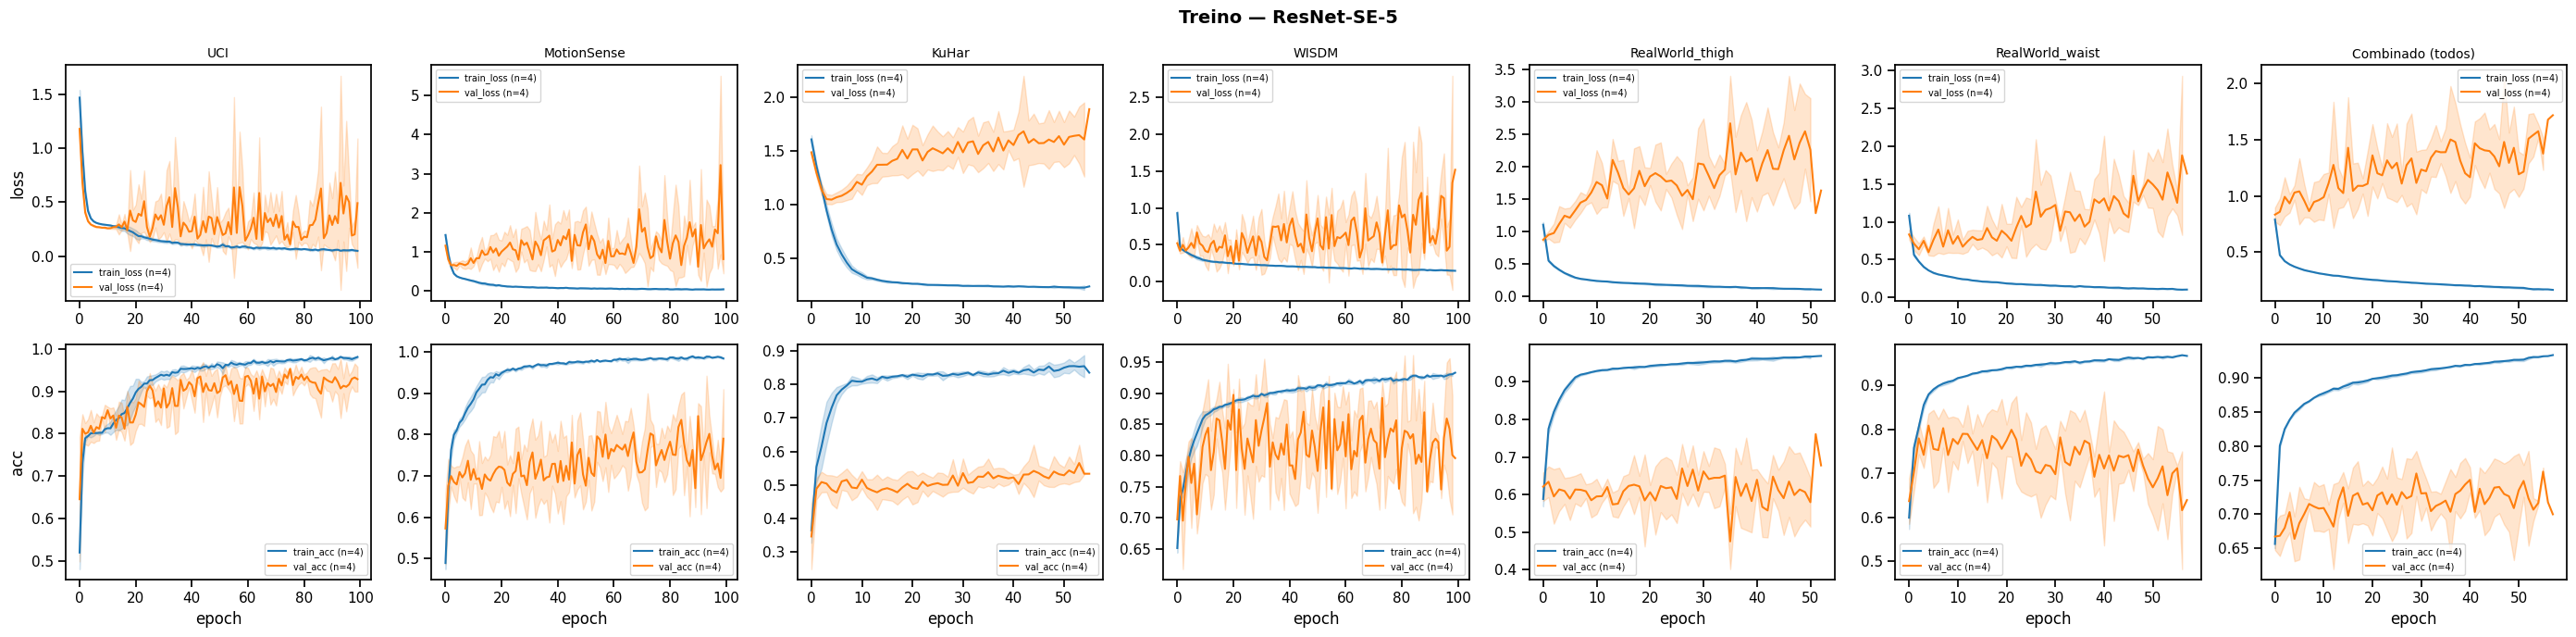

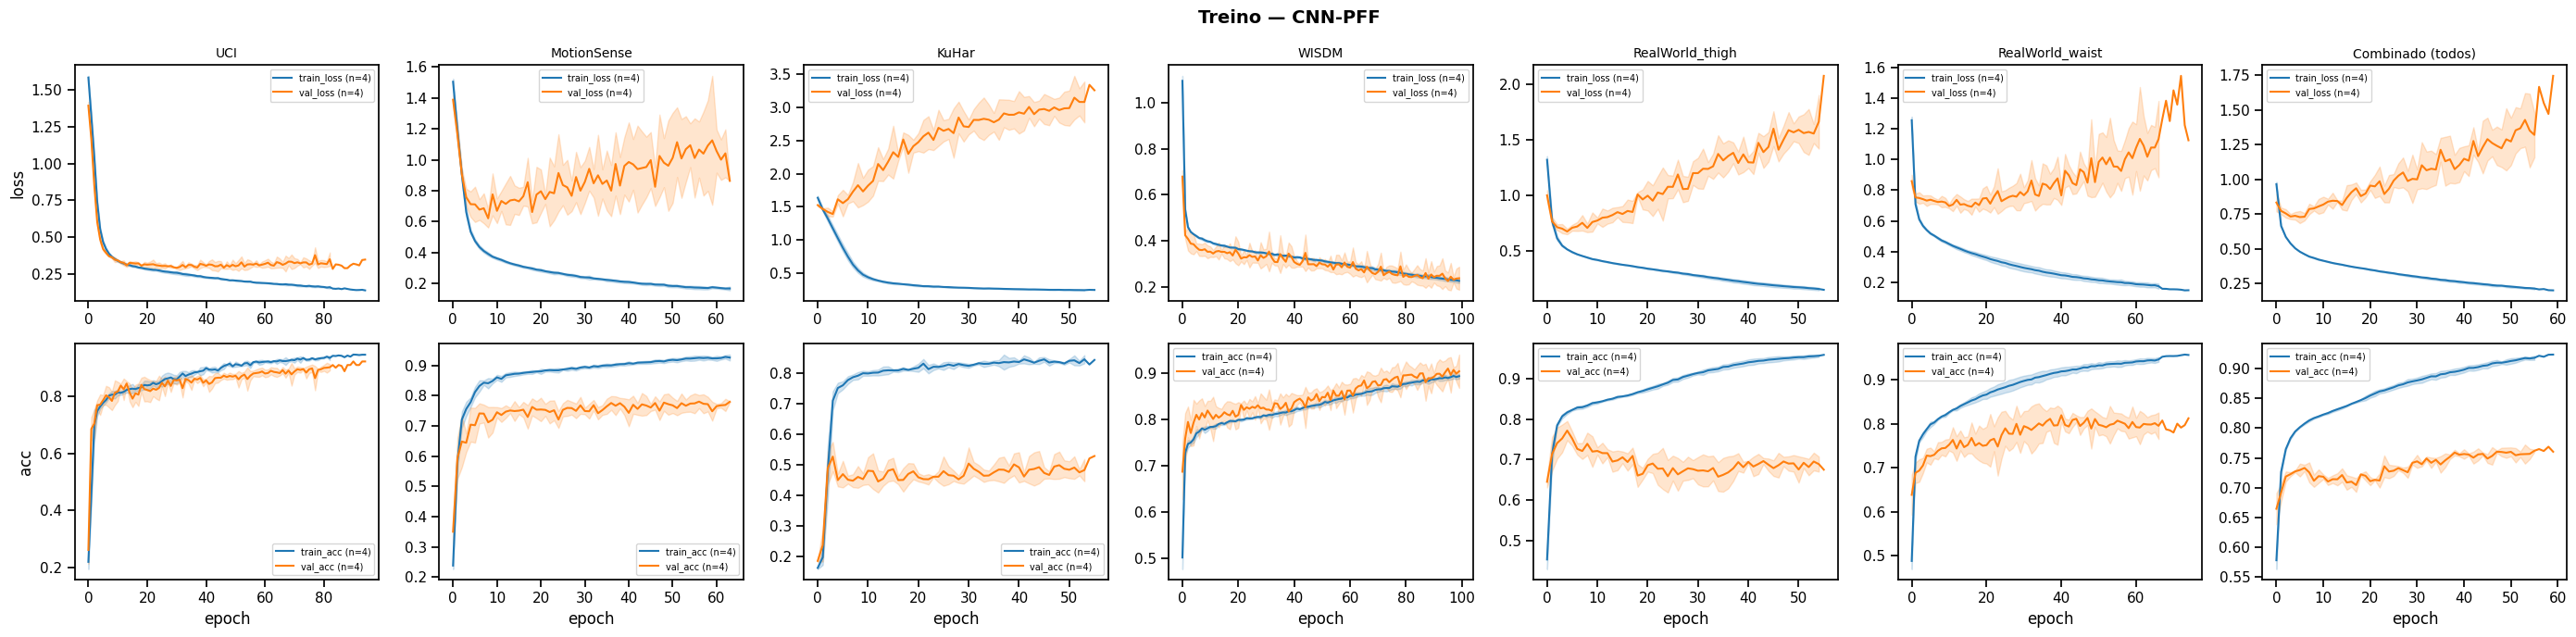

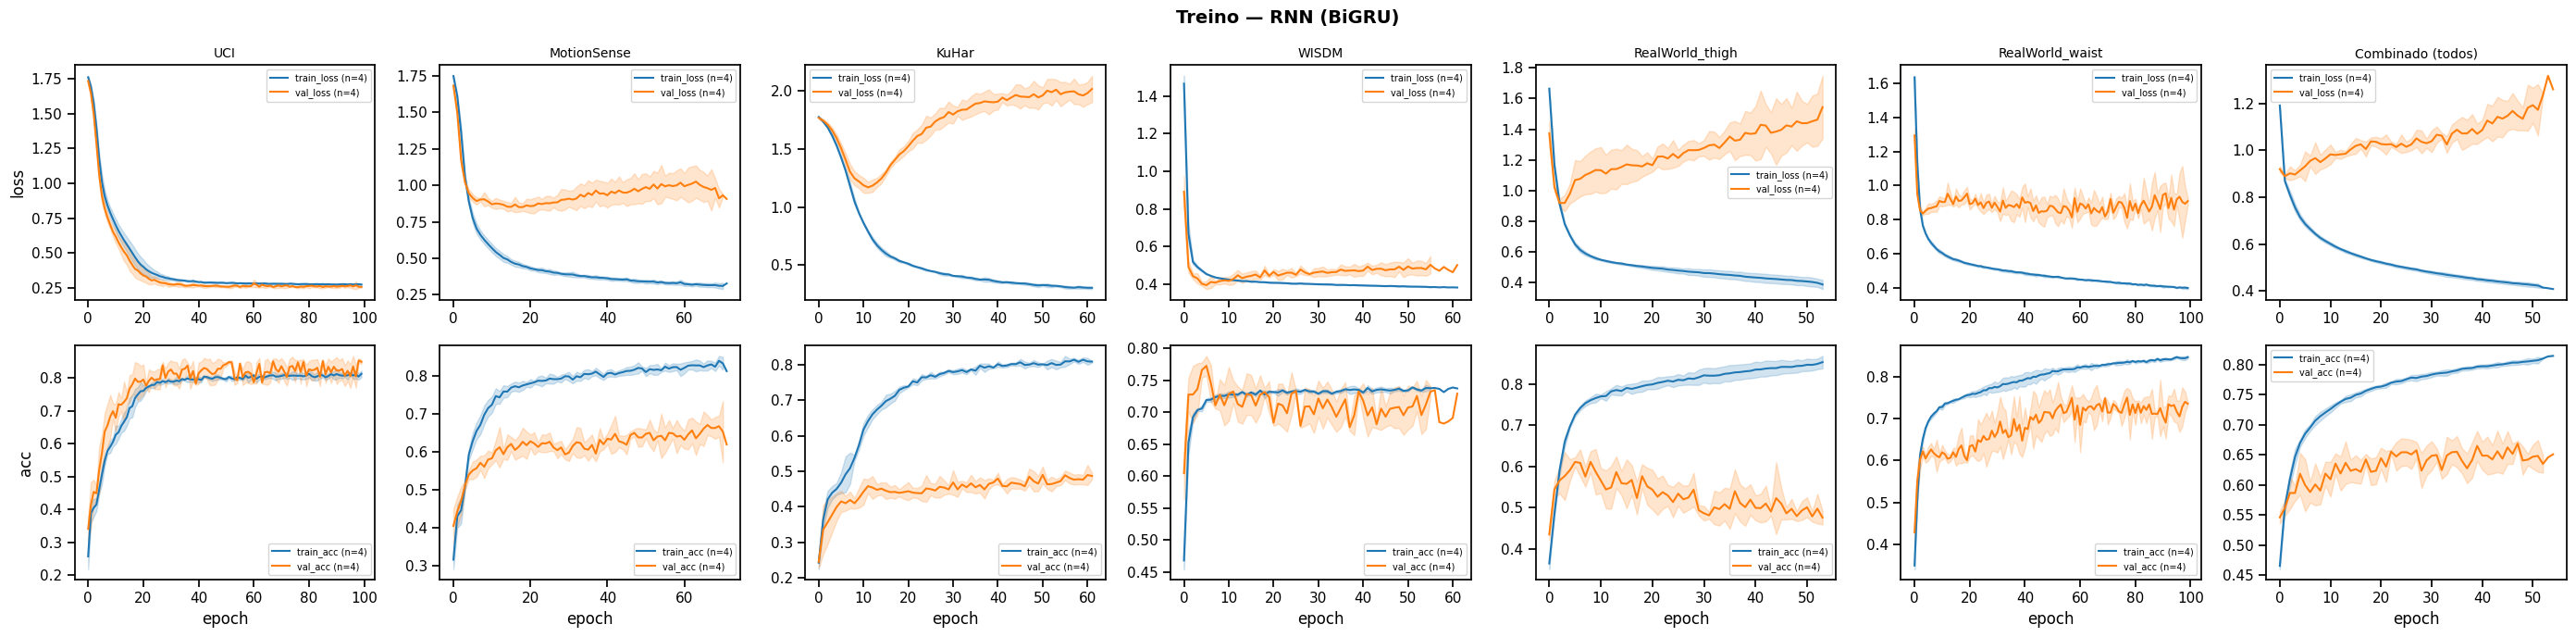

In [6]:
def collect_curve(encoder: str, dataset: str, metric: str):
    """Retorna (epochs, mean, std, n_seeds) para `metric` ao longo das seeds."""
    per_seed = {}
    for seed in SEEDS:
        df = safe_read_metrics(encoder, dataset, seed)
        if df is None or metric not in df.columns:
            continue
        sub = df[["epoch", metric]].dropna()
        if sub.empty:
            continue
        per_seed[seed] = sub.groupby("epoch")[metric].last()
    if not per_seed:
        return None
    aligned = pd.concat(per_seed, axis=1)
    return aligned.index.values, aligned.mean(axis=1).values, aligned.std(axis=1).values, len(per_seed)


def _curve_title(dataset: str) -> str:
    return COMBINED_PRETTY if dataset == COMBINED else dataset


def plot_training_curves():
    for encoder in ENCODERS:
        fig, axes = plt.subplots(2, len(CURVE_DATASETS), figsize=(4 * len(CURVE_DATASETS), 7), sharex=False)
        fig.suptitle(f"Treino — {ENCODER_PRETTY[encoder]}", fontsize=14, fontweight="bold")
        for j, dataset in enumerate(CURVE_DATASETS):
            ax_loss = axes[0, j]
            ax_acc = axes[1, j]
            ax_loss.set_title(_curve_title(dataset), fontsize=10)
            any_data = False
            for metric, color in [("train_loss", "tab:blue"), ("val_loss", "tab:orange")]:
                c = collect_curve(encoder, dataset, metric)
                if c is None:
                    continue
                any_data = True
                ep, m, s, n = c
                ax_loss.plot(ep, m, color=color, label=f"{metric} (n={n})")
                ax_loss.fill_between(ep, m - s, m + s, alpha=0.2, color=color)
            for metric, color in [("train_acc", "tab:blue"), ("val_acc", "tab:orange")]:
                c = collect_curve(encoder, dataset, metric)
                if c is None:
                    continue
                any_data = True
                ep, m, s, n = c
                ax_acc.plot(ep, m, color=color, label=f"{metric} (n={n})")
                ax_acc.fill_between(ep, m - s, m + s, alpha=0.2, color=color)
            if any_data:
                ax_loss.legend(fontsize=7)
                ax_acc.legend(fontsize=7)
                if j == 0:
                    ax_loss.set_ylabel("loss")
                    ax_acc.set_ylabel("acc")
                ax_acc.set_xlabel("epoch")
            else:
                for ax in (ax_loss, ax_acc):
                    ax.text(0.5, 0.5, "sem dados", ha="center", va="center", transform=ax.transAxes, color="gray")
                    ax.set_xticks([])
                    ax.set_yticks([])
        plt.tight_layout()
        plt.show()


plot_training_curves()

## 4. Avaliação in-distribution e transfer learning

Para cada `(encoder, source, seed)` com `best.ckpt` disponível, avaliamos o modelo nos test sets dos 6 datasets DAGHAR (zero-shot, sem fine-tune). As fontes incluem os 6 datasets individuais **e** o modelo `combined` (treinado na união de todos); os alvos são sempre os 6 datasets reais. A diagonal `source == target` é a avaliação in-distribution. Resultados são cacheados em `results/supervised_eval_transfer.csv` — para forçar reavaliação, deletar o CSV ou passar `force=True`.

In [7]:
# A avaliação de transfer (acurácia + F1-macro) é feita pelo script
# `scripts/eval_transfer.py`, que carrega cada best.ckpt, avalia nos 6 alvos e
# escreve o cache em results/. Aqui o notebook apenas LÊ esse cache.
#
# Para (re)gerar os resultados:
#     python scripts/eval_transfer.py            # calcula o que falta
#     python scripts/eval_transfer.py --force    # recalcula tudo
CACHE_COLS = ["encoder", "source", "seed", "target", "test_acc", "test_f1_macro"]


def load_transfer_cache() -> pd.DataFrame:
    if not TRANSFER_CACHE.exists():
        print(f"Cache não encontrado em {TRANSFER_CACHE}.\n"
              f"Rode: python scripts/eval_transfer.py")
        return pd.DataFrame(columns=CACHE_COLS)
    df = pd.read_csv(TRANSFER_CACHE)
    for col in CACHE_COLS:
        if col not in df.columns:
            df[col] = pd.NA
    return df[CACHE_COLS]


transfer_df = load_transfer_cache()
print(f"{len(transfer_df)} resultados no cache ({TRANSFER_CACHE.name}) — "
      f"colunas: {list(transfer_df.columns)}")
transfer_df.head()


504 resultados no cache (supervised_eval_transfer.csv) — colunas: ['encoder', 'source', 'seed', 'target', 'test_acc', 'test_f1_macro']


,encoder,source,seed,target,test_acc,test_f1_macro
0,cnnpff,KuHar,0,KuHar,0.718750,0.617301
1,cnnpff,KuHar,0,MotionSense,0.433594,0.310616
2,cnnpff,KuHar,0,RealWorld_thigh,0.434375,0.317086
3,cnnpff,KuHar,0,RealWorld_waist,0.554297,0.483465
4,cnnpff,KuHar,0,UCI,0.337500,0.220289


### 4.1 Tabela in-distribution (test_acc e F1-macro %, média ± std das 4 seeds)

In [8]:
def format_mean_std(mean, std):
    if pd.isna(mean):
        return "—"
    if pd.isna(std):
        return f"{mean * 100:.2f}"
    return f"{mean * 100:.2f} ± {std * 100:.2f}"


def indist_table(metric: str) -> pd.DataFrame:
    """Tabela in-distribution (source == target) para a métrica dada,
    formatada como média ± std (%) das 4 seeds, encoders nas colunas."""
    indist = transfer_df[transfer_df["source"] == transfer_df["target"]]
    agg = indist.groupby(["encoder", "source"])[metric].agg(["mean", "std"]).reset_index()
    pm = agg.pivot(index="source", columns="encoder", values="mean").reindex(index=DATASETS, columns=ENCODERS)
    ps = agg.pivot(index="source", columns="encoder", values="std").reindex(index=DATASETS, columns=ENCODERS)
    out = pm.copy().astype(object)
    for ds in DATASETS:
        for enc in ENCODERS:
            out.loc[ds, enc] = format_mean_std(pm.loc[ds, enc], ps.loc[ds, enc])
    out.columns = [ENCODER_PRETTY[c] for c in out.columns]
    out.index.name = "Dataset"
    return out


if transfer_df.empty:
    print("Sem resultados — rode `python scripts/eval_transfer.py` primeiro.")
else:
    print("In-distribution — Acurácia (%, média ± std das 4 seeds):")
    display(indist_table("test_acc"))
    print("\nIn-distribution — F1-macro (%, média ± std das 4 seeds):")
    display(indist_table("test_f1_macro"))


In-distribution — Acurácia (%, média ± std das 4 seeds):


,ResNet-SE-5,CNN-PFF,RNN (BiGRU)
Dataset,,,
UCI,95.39 ± 0.73,88.83 ± 0.92,85.16 ± 0.89
MotionSense,89.53 ± 7.17,83.69 ± 3.94,75.93 ± 1.72
KuHar,69.14 ± 10.57,71.48 ± 5.51,52.73 ± 3.03
WISDM,85.48 ± 1.50,86.81 ± 0.70,73.63 ± 2.64
RealWorld_thigh,69.71 ± 1.92,75.75 ± 0.13,61.65 ± 2.27
RealWorld_waist,72.89 ± 3.14,70.74 ± 1.96,68.58 ± 1.34



In-distribution — F1-macro (%, média ± std das 4 seeds):


,ResNet-SE-5,CNN-PFF,RNN (BiGRU)
Dataset,,,
UCI,94.43 ± 0.88,84.39 ± 2.10,75.77 ± 2.31
MotionSense,88.37 ± 9.36,82.37 ± 6.38,72.06 ± 2.98
KuHar,62.98 ± 13.09,63.75 ± 7.06,41.89 ± 3.00
WISDM,85.24 ± 1.49,86.58 ± 0.74,66.86 ± 4.44
RealWorld_thigh,66.82 ± 4.00,75.97 ± 0.33,59.14 ± 3.59
RealWorld_waist,72.14 ± 2.92,71.12 ± 2.11,65.81 ± 0.50


### 4.2 Matriz transfer learning 7×6 (zero-shot)

Linha = dataset (ou união) usado para treinar; a **primeira linha** é o modelo combinado (treinado em todos). Coluna = dataset usado para avaliar. Cada célula mostra `mean ± std (%)` agregando as 4 seeds. A diagonal das 6 linhas de baixo = avaliação in-distribution.

Uma figura por encoder + uma figura **agregada** (média dos 3 encoders × seeds por par source→target) ao final.

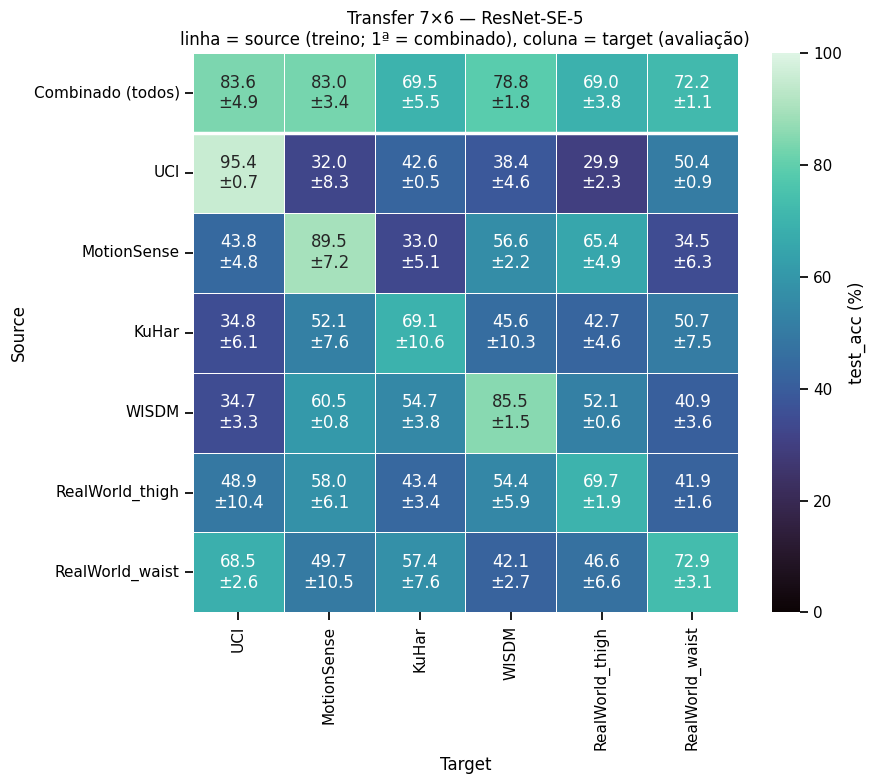

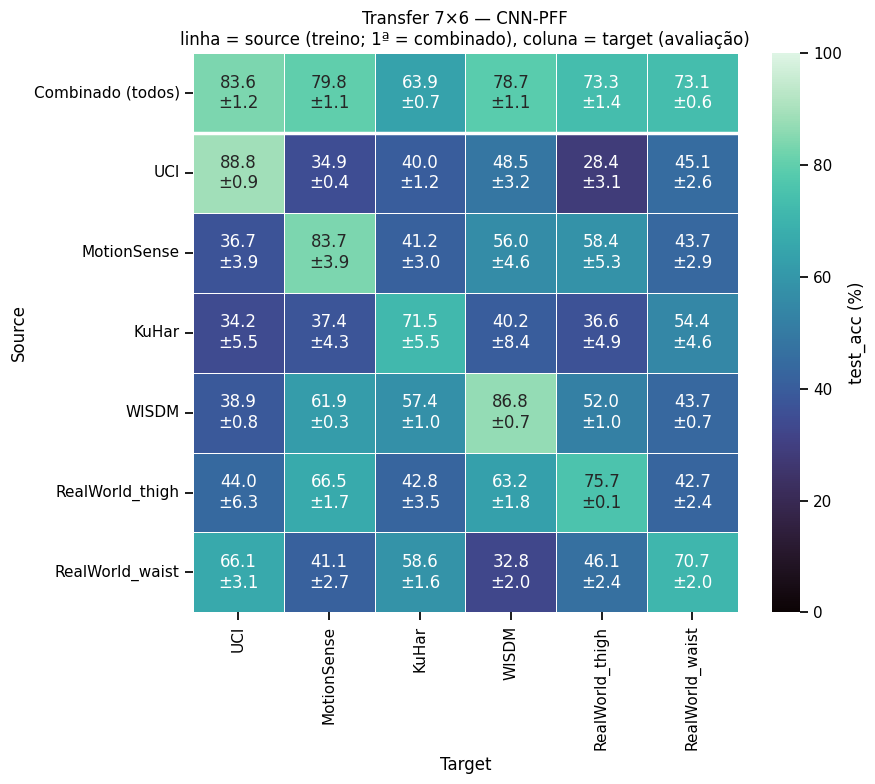

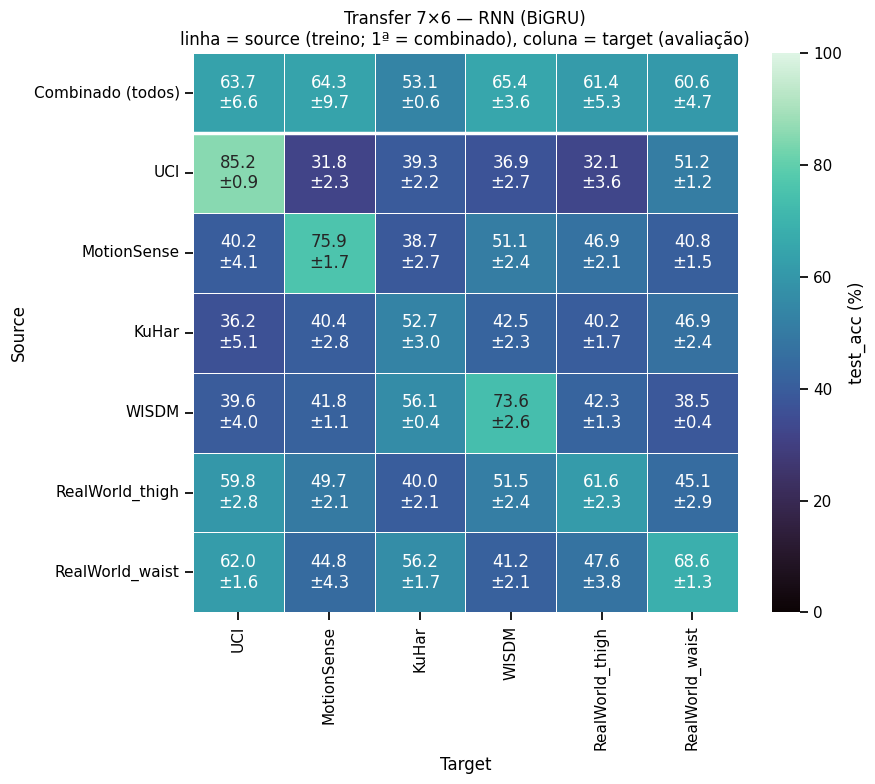

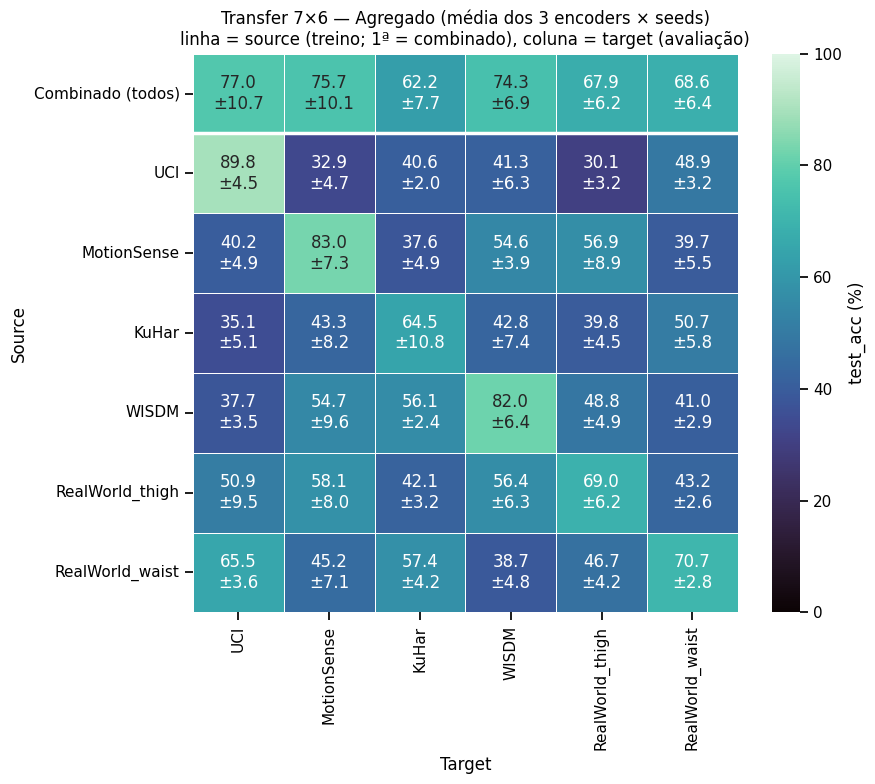

In [9]:
def _draw_transfer_heatmap(sub: pd.DataFrame, title: str):
    """Desenha um heatmap 7×6 source→target (mean ± std %) a partir de um
    recorte do cache. `sub` pode ser um único encoder ou todos (agregado)."""
    sub = sub.assign(test_acc=pd.to_numeric(sub["test_acc"], errors="coerce"))
    agg = sub.groupby(["source", "target"])["test_acc"].agg(["mean", "std"]).reset_index()
    # Linhas = fontes (combinado primeiro + 6 datasets); colunas = 6 alvos reais.
    mean_mat = agg.pivot(index="source", columns="target", values="mean").reindex(index=TRANSFER_SOURCES, columns=DATASETS).astype(float)
    std_mat = agg.pivot(index="source", columns="target", values="std").reindex(index=TRANSFER_SOURCES, columns=DATASETS).astype(float)
    annot = np.empty_like(mean_mat.values, dtype=object)
    for i in range(mean_mat.shape[0]):
        for j in range(mean_mat.shape[1]):
            m, s = mean_mat.values[i, j], std_mat.values[i, j]
            if pd.isna(m):
                annot[i, j] = ""
            elif pd.isna(s):
                annot[i, j] = f"{m * 100:.1f}"
            else:
                annot[i, j] = f"{m * 100:.1f}\n±{s * 100:.1f}"
    # Renomeia só o rótulo da linha do modelo combinado (ordem das linhas
    # permanece a mesma, então o `annot` posicional continua alinhado).
    mean_disp = mean_mat.rename(index={COMBINED: COMBINED_PRETTY})
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(
        mean_disp * 100,
        annot=annot,
        fmt="",
        cmap=HEATMAP_CMAP,
        vmin=0,
        vmax=100,
        cbar_kws={"label": "test_acc (%)"},
        ax=ax,
        linewidths=0.5,
    )
    # Separa visualmente a 1ª linha (modelo combinado) das fontes single-source.
    ax.axhline(1, color="white", linewidth=2.5)
    ax.set_title(title)
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")
    plt.tight_layout()
    plt.show()


def plot_transfer_heatmaps():
    if transfer_df.empty:
        print("Sem dados de transferência.")
        return
    for encoder in ENCODERS:
        sub = transfer_df[transfer_df["encoder"] == encoder]
        if sub.empty:
            print(f"[{encoder}] sem dados.")
            continue
        _draw_transfer_heatmap(
            sub,
            f"Transfer 7×6 — {ENCODER_PRETTY[encoder]}\n"
            "linha = source (treino; 1ª = combinado), coluna = target (avaliação)",
        )
    # Heatmap agregado: média sobre os 3 encoders (× 4 seeds) por par source→target.
    _draw_transfer_heatmap(
        transfer_df,
        "Transfer 7×6 — Agregado (média dos 3 encoders × seeds)\n"
        "linha = source (treino; 1ª = combinado), coluna = target (avaliação)",
    )


plot_transfer_heatmaps()

### 4.3 Generalização do modelo combinado (treino com todos os datasets juntos)

O modelo **combinado** é treinado uma única vez sobre a união dos 6 datasets DAGHAR (`scripts/train_supervised_combined.py`) e avaliado em cada test set individual. Para cada encoder, comparamos por dataset alvo três cenários:

- **Especialista (in-dist)** — modelo treinado e avaliado no próprio dataset (a diagonal da matriz 4.2). É o teto prático.
- **Transfer médio (single→target)** — média zero-shot dos 5 especialistas de *outros* datasets avaliados no alvo (off-diagonal da coluna).
- **Combinado (todos→target)** — o modelo generalista avaliado no alvo.

A tabela-resumo agrega as médias entre os 6 alvos e mostra o ganho (em pontos percentuais) do combinado sobre a transferência single-source e o quanto ele ainda fica abaixo do especialista dedicado.

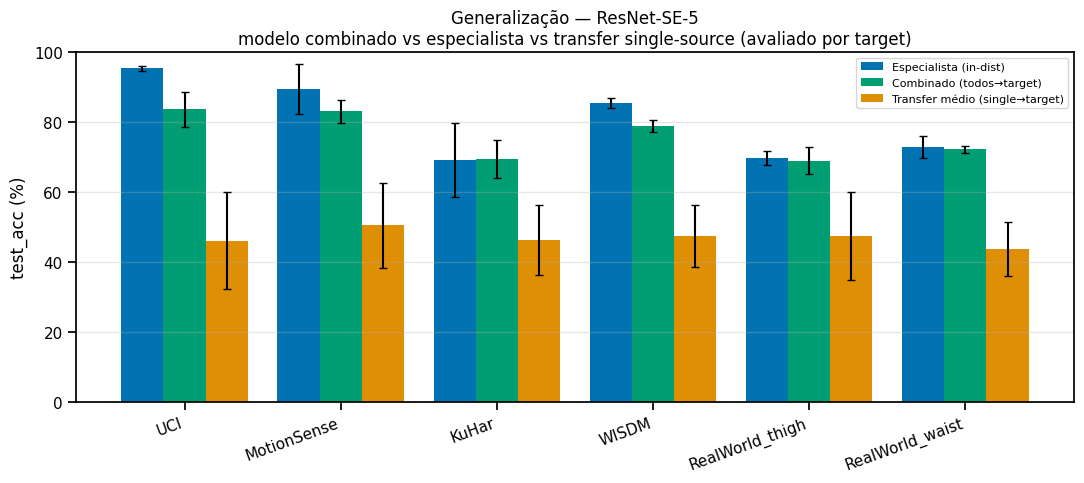

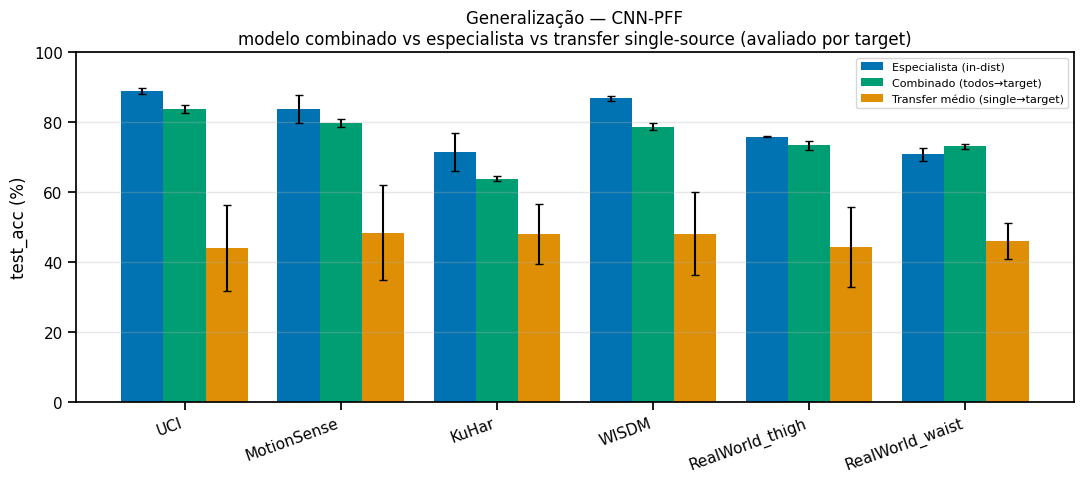

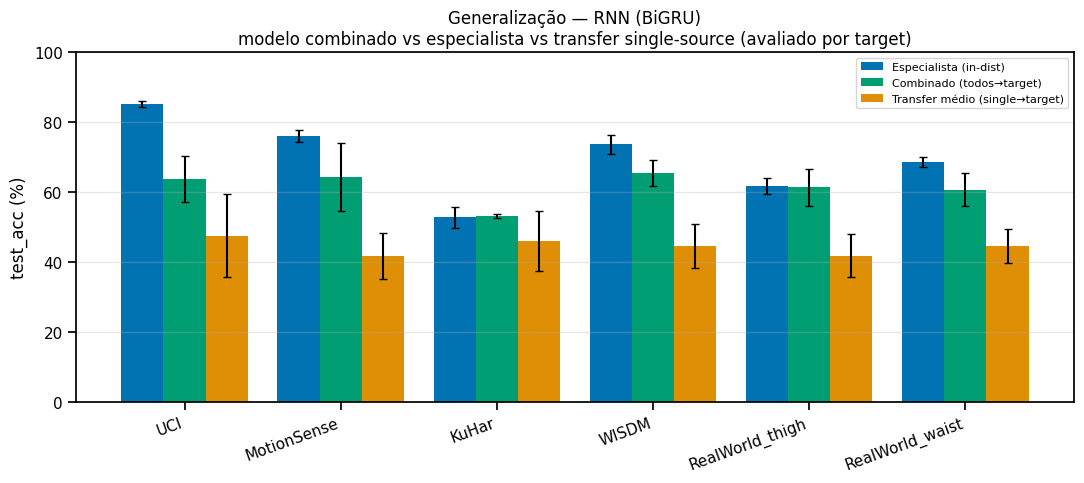

Médias entre os 6 datasets alvo (test_acc %):


,Especialista (in-dist) %,Transfer single médio %,Combinado %,Δ vs single (pp),Δ vs especialista (pp)
Encoder,,,,,
ResNet-SE-5,80.36,46.88,76.04,29.16,-4.32
CNN-PFF,79.55,46.45,75.40,28.95,-4.15
RNN (BiGRU),69.61,44.38,61.42,17.05,-8.19


In [10]:
def _mean_std_acc(df: pd.DataFrame, encoder: str, source: str, target: str):
    """(mean, std, n) de test_acc para um trio (encoder, source, target)."""
    sel = df[(df["encoder"] == encoder) & (df["source"] == source) & (df["target"] == target)]
    vals = pd.to_numeric(sel["test_acc"], errors="coerce").dropna()
    if vals.empty:
        return np.nan, np.nan, 0
    return vals.mean(), vals.std(), len(vals)


def plot_combined_generalization():
    """Compara, por dataset alvo, o modelo combinado (treinado em todos) contra
    o especialista in-distribution e a transferência média single-source."""
    if transfer_df.empty:
        print("Sem dados de avaliação.")
        return
    if not (transfer_df["source"] == COMBINED).any():
        print(
            f"Sem checkpoints do modelo combinado (source='{COMBINED}'). "
            "Rode `scripts/train_supervised_combined.py` e reexecute a Seção 4."
        )
        return

    x = np.arange(len(DATASETS))
    width = 0.27
    summary_rows = []
    for encoder in ENCODERS:
        spec_m, spec_s, single_m, single_s, comb_m, comb_s = ([] for _ in range(6))
        for target in DATASETS:
            cm, cs, _ = _mean_std_acc(transfer_df, encoder, COMBINED, target)        # combinado -> target
            sm, ss, _ = _mean_std_acc(transfer_df, encoder, target, target)          # especialista (in-dist)
            # Transferência média zero-shot dos especialistas single-source (source != target):
            single = transfer_df[
                (transfer_df["encoder"] == encoder)
                & (transfer_df["target"] == target)
                & (transfer_df["source"].isin(DATASETS))
                & (transfer_df["source"] != target)
            ]
            sv = pd.to_numeric(single["test_acc"], errors="coerce").dropna()
            spec_m.append(sm * 100); spec_s.append((ss if not pd.isna(ss) else 0) * 100)
            single_m.append(sv.mean() * 100 if not sv.empty else np.nan)
            single_s.append(sv.std() * 100 if not sv.empty else 0)
            comb_m.append(cm * 100); comb_s.append((cs if not pd.isna(cs) else 0) * 100)
            summary_rows.append({
                "encoder": encoder,
                "target": target,
                "especialista": sm,
                "transfer_single_medio": sv.mean() if not sv.empty else np.nan,
                "combinado": cm,
            })

        fig, ax = plt.subplots(figsize=(11, 5))
        # Ordem das barras: Especialista / Combinado / Transfer.
        ax.bar(x - width, spec_m, width, yerr=spec_s, capsize=3, label="Especialista (in-dist)", color=SCENARIO_COLORS["especialista"])
        ax.bar(x, comb_m, width, yerr=comb_s, capsize=3, label="Combinado (todos→target)", color=SCENARIO_COLORS["combinado"])
        ax.bar(x + width, single_m, width, yerr=single_s, capsize=3, label="Transfer médio (single→target)", color=SCENARIO_COLORS["transfer"])
        ax.set_xticks(x)
        ax.set_xticklabels(DATASETS, rotation=20, ha="right")
        ax.set_ylabel("test_acc (%)")
        ax.set_ylim(0, 100)
        ax.set_title(
            f"Generalização — {ENCODER_PRETTY[encoder]}\n"
            "modelo combinado vs especialista vs transfer single-source (avaliado por target)"
        )
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Resumo: média entre os 6 targets + ganho do combinado sobre o transfer single.
    summary = pd.DataFrame(summary_rows)
    agg = summary.groupby("encoder")[["especialista", "transfer_single_medio", "combinado"]].mean()
    agg = agg.reindex(ENCODERS)
    agg["Δ combinado − single"] = agg["combinado"] - agg["transfer_single_medio"]
    agg["Δ combinado − especialista"] = agg["combinado"] - agg["especialista"]
    agg = (agg * 100).round(2)
    agg.index = [ENCODER_PRETTY[e] for e in agg.index]
    agg.index.name = "Encoder"
    agg.columns = [
        "Especialista (in-dist) %",
        "Transfer single médio %",
        "Combinado %",
        "Δ vs single (pp)",
        "Δ vs especialista (pp)",
    ]
    print("Médias entre os 6 datasets alvo (test_acc %):")
    display(agg)


plot_combined_generalization()

### 4.4 Comparação dos 3 cenários (baseline vs combinado vs transfer out-domain)

Gráficos de barra agregando **todos os encoders e todas as seeds** por dataset alvo, comparando os três cenários de avaliação (ordem das barras: **Especialista / Combinado / Transfer**):

1. **Baseline / Especialista (próprio → próprio)** — modelo treinado e avaliado no próprio dataset (in-distribution); é o teto prático.
2. **Combinado (todos → próprio)** — modelo treinado na união dos 6 datasets e avaliado em um só (generalização a partir de treino multi-domínio).
3. **Transfer out-domain (outros → próprio)** — modelos treinados em *outros* datasets e avaliados no próprio (transfer learning zero-shot, média sobre as 5 fontes externas).

Diferente da Seção 4.3 (uma figura por encoder), aqui cada barra é a média **pooled** sobre os 3 encoders × 4 seeds; a barra de erro é o desvio-padrão dessa população.

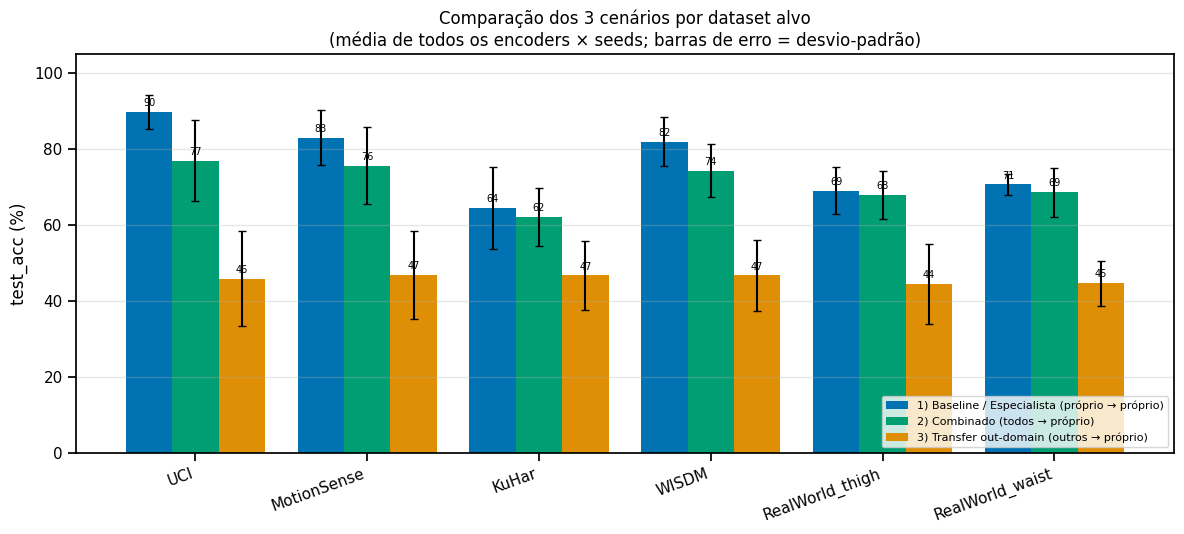

Médias agregando todos os encoders × seeds (test_acc %):


,1) Baseline %,2) Combinado %,3) Transfer out-domain %
Target,,,
UCI,89.79,76.99,45.89
MotionSense,83.05,75.69,46.85
KuHar,64.45,62.17,46.76
WISDM,81.97,74.32,46.73
RealWorld_thigh,69.04,67.90,44.48
RealWorld_waist,70.74,68.64,44.69
Média (6 alvos),76.51,70.95,45.90


In [11]:
def plot_three_case_comparison():
    """Barras por dataset alvo agregando TODOS os encoders × seeds, comparando
    os três cenários de avaliação (ordem das barras: Especialista / Combinado /
    Transfer):

    1) Baseline / Especialista (próprio → próprio): modelo treinado e avaliado no
       mesmo dataset (in-distribution).
    2) Combinado (todos → próprio): modelo treinado na união dos 6 datasets e
       avaliado em um só — generalização a partir de treino multi-domínio.
    3) Transfer out-domain (outros → próprio): modelos treinados em *outros*
       datasets e avaliados no próprio (transfer learning zero-shot, média sobre
       as 5 fontes externas).
    """
    if transfer_df.empty:
        print("Sem dados de avaliação.")
        return
    df = transfer_df.assign(test_acc=pd.to_numeric(transfer_df["test_acc"], errors="coerce"))

    def pool(mask):
        """(mean%, std%, n) de test_acc sobre todos os encoders × seeds do recorte."""
        vals = df.loc[mask, "test_acc"].dropna()
        if vals.empty:
            return np.nan, 0.0, 0
        return vals.mean() * 100, vals.std() * 100, len(vals)

    cases = []
    for target in DATASETS:
        base = pool((df["source"] == target) & (df["target"] == target))
        comb = pool((df["source"] == COMBINED) & (df["target"] == target))
        out = pool(
            (df["target"] == target)
            & (df["source"].isin(DATASETS))
            & (df["source"] != target)
        )
        cases.append((target, base, comb, out))

    targets = [c[0] for c in cases]
    base_m = [c[1][0] for c in cases]; base_s = [c[1][1] for c in cases]
    comb_m = [c[2][0] for c in cases]; comb_s = [c[2][1] for c in cases]
    out_m = [c[3][0] for c in cases]; out_s = [c[3][1] for c in cases]

    x = np.arange(len(targets))
    width = 0.27
    fig, ax = plt.subplots(figsize=(12, 5.5))
    # Ordem das barras: Especialista / Combinado / Transfer.
    bars = [
        (base_m, base_s, -width, SCENARIO_COLORS["especialista"], "1) Baseline / Especialista (próprio → próprio)"),
        (comb_m, comb_s, 0.0, SCENARIO_COLORS["combinado"], "2) Combinado (todos → próprio)"),
        (out_m, out_s, width, SCENARIO_COLORS["transfer"], "3) Transfer out-domain (outros → próprio)"),
    ]
    for m, s, off, color, label in bars:
        ax.bar(x + off, m, width, yerr=s, capsize=3, color=color, label=label)
        for xi, v in zip(x, m):
            if not pd.isna(v):
                ax.text(xi + off, v + 1, f"{v:.0f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(targets, rotation=20, ha="right")
    ax.set_ylabel("test_acc (%)")
    ax.set_ylim(0, 105)
    ax.set_title(
        "Comparação dos 3 cenários por dataset alvo\n"
        "(média de todos os encoders × seeds; barras de erro = desvio-padrão)"
    )
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Tabela-resumo (média entre os 6 alvos na última linha). Colunas na mesma
    # ordem das barras: Especialista / Combinado / Transfer.
    rows = [
        {
            "Target": target,
            "1) Baseline %": base[0],
            "2) Combinado %": comb[0],
            "3) Transfer out-domain %": out[0],
        }
        for target, base, comb, out in cases
    ]
    tab = pd.DataFrame(rows).set_index("Target")
    tab.loc["Média (6 alvos)"] = tab.mean()
    print("Médias agregando todos os encoders × seeds (test_acc %):")
    display(tab.round(2))


plot_three_case_comparison()

## 5. t-SNE dos encoders — epoch 0 / last / best (seed 0)

Para cada `(encoder, dataset)` na seed 0, extrai embeddings do backbone para o test set do dataset e plota 3 t-SNEs lado-a-lado: `first.ckpt` (≈ epoch 0), `last.ckpt` (última época), `best.ckpt` (melhor val_loss). Cores = atividade real. A primeira figura de cada encoder é o modelo **Combinado (todos)**, avaliado no test set conjunto.

Using DataLoader with shuffle=False


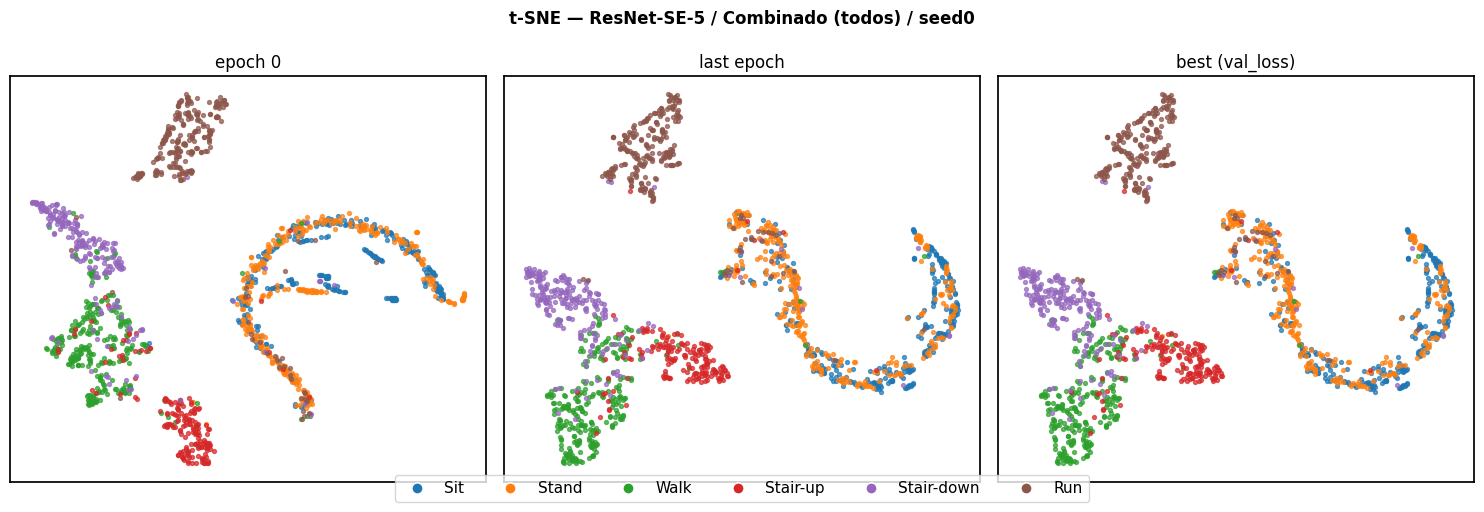

Using DataLoader with shuffle=False


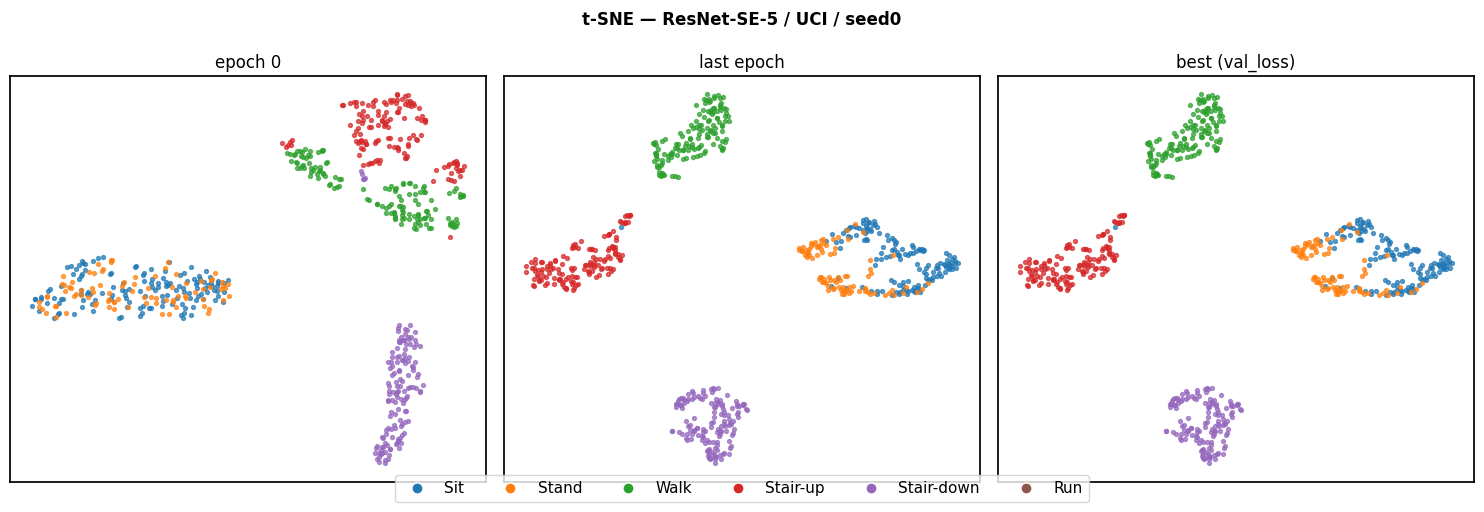

Using DataLoader with shuffle=False


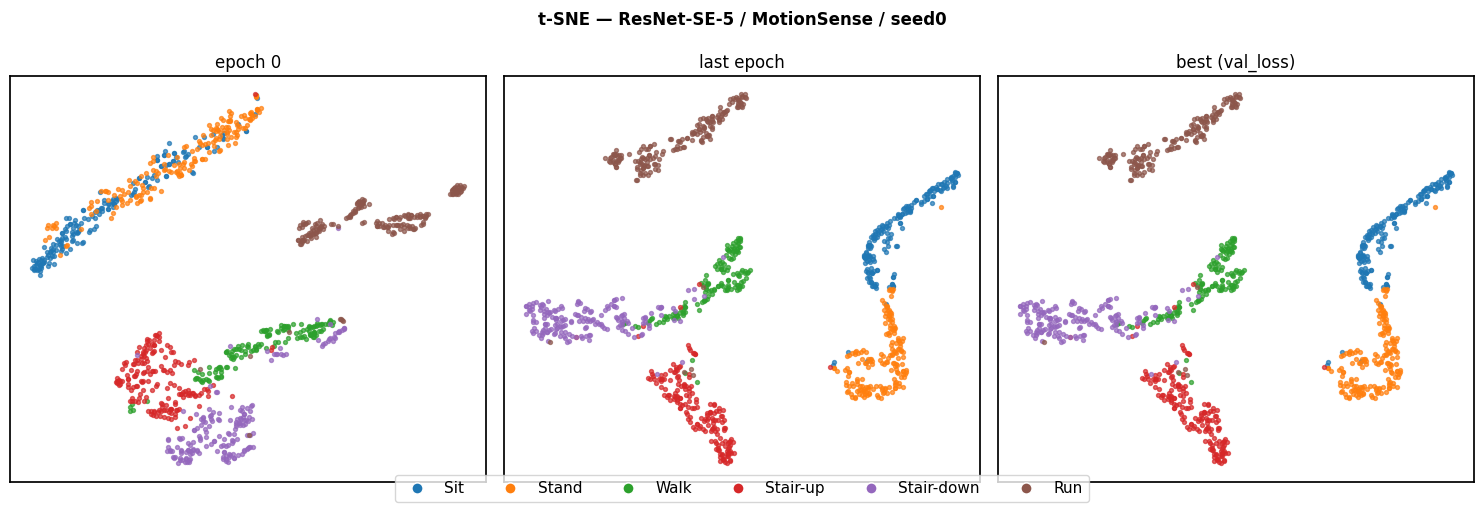

Using DataLoader with shuffle=False


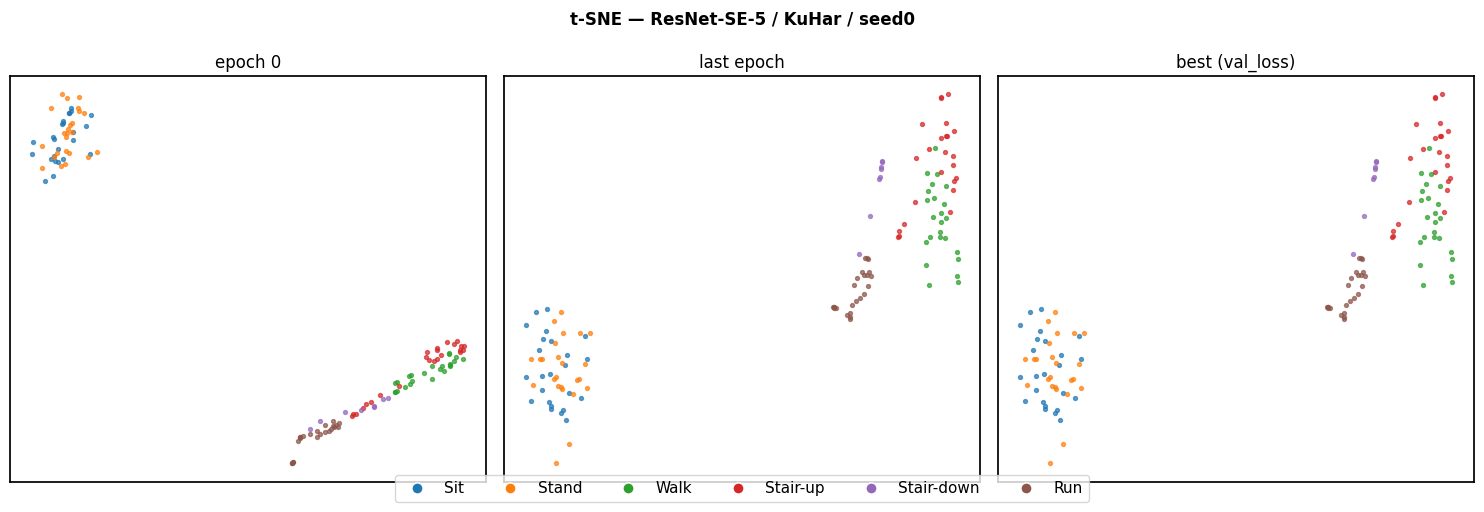

Using DataLoader with shuffle=False


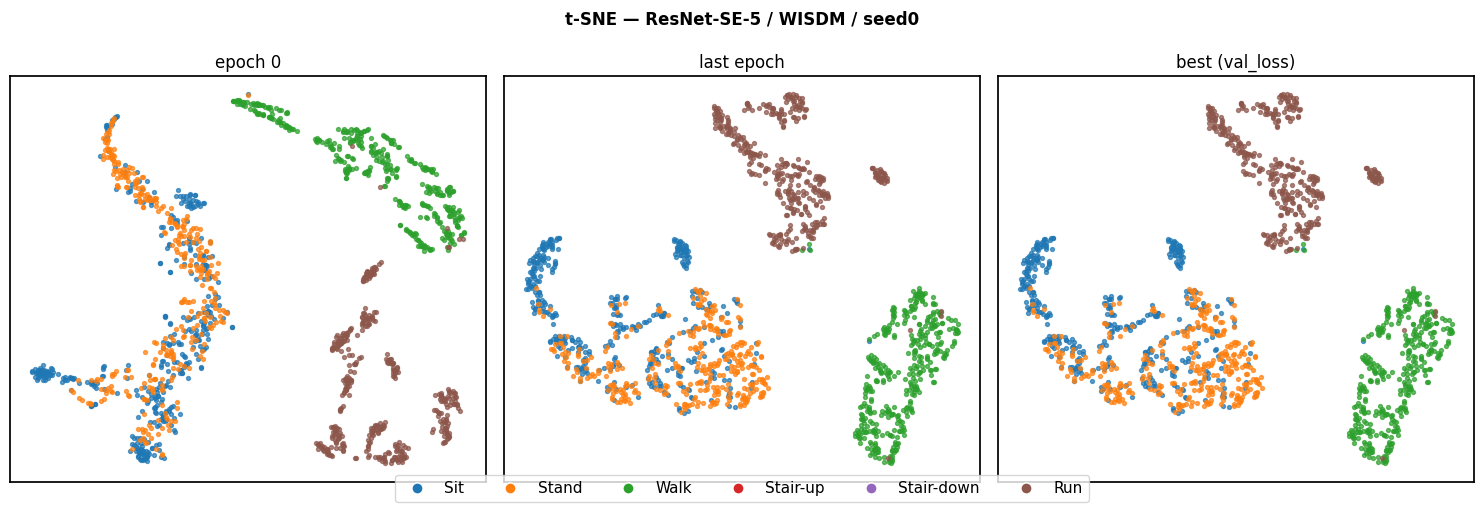

Using DataLoader with shuffle=False


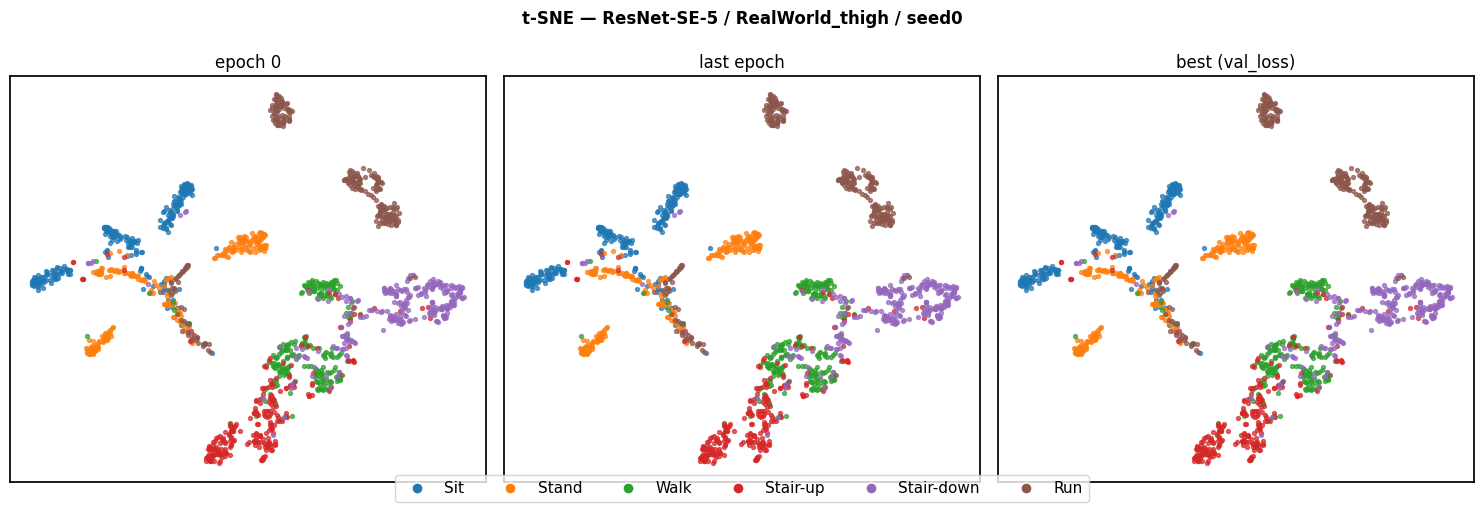

Using DataLoader with shuffle=False


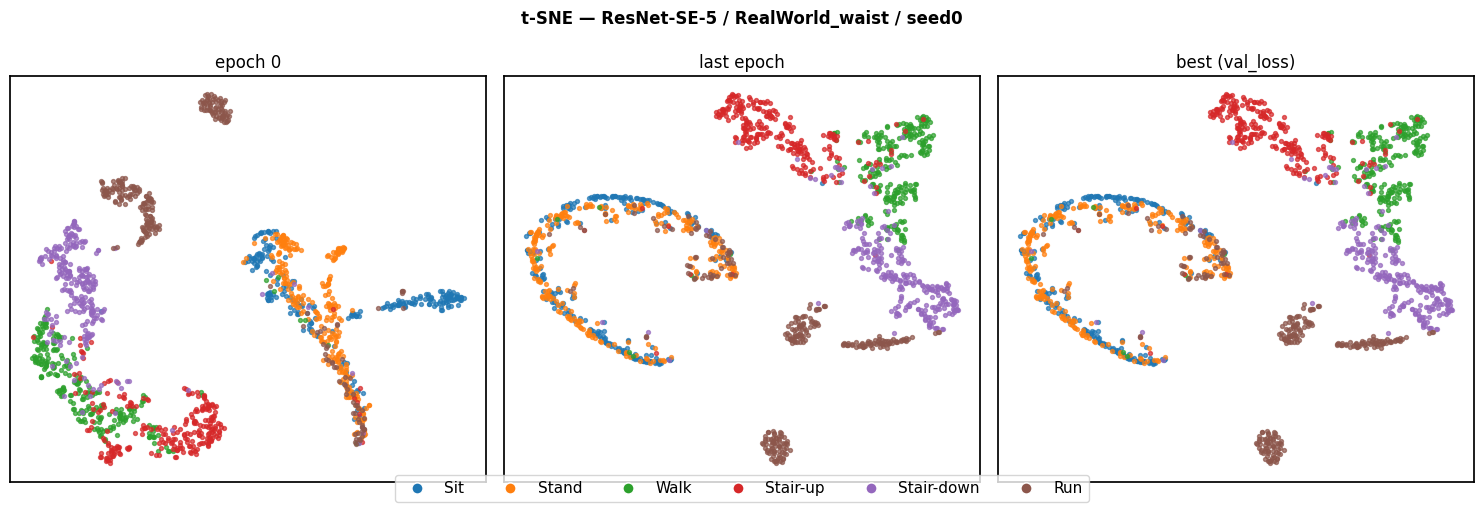

Using DataLoader with shuffle=False


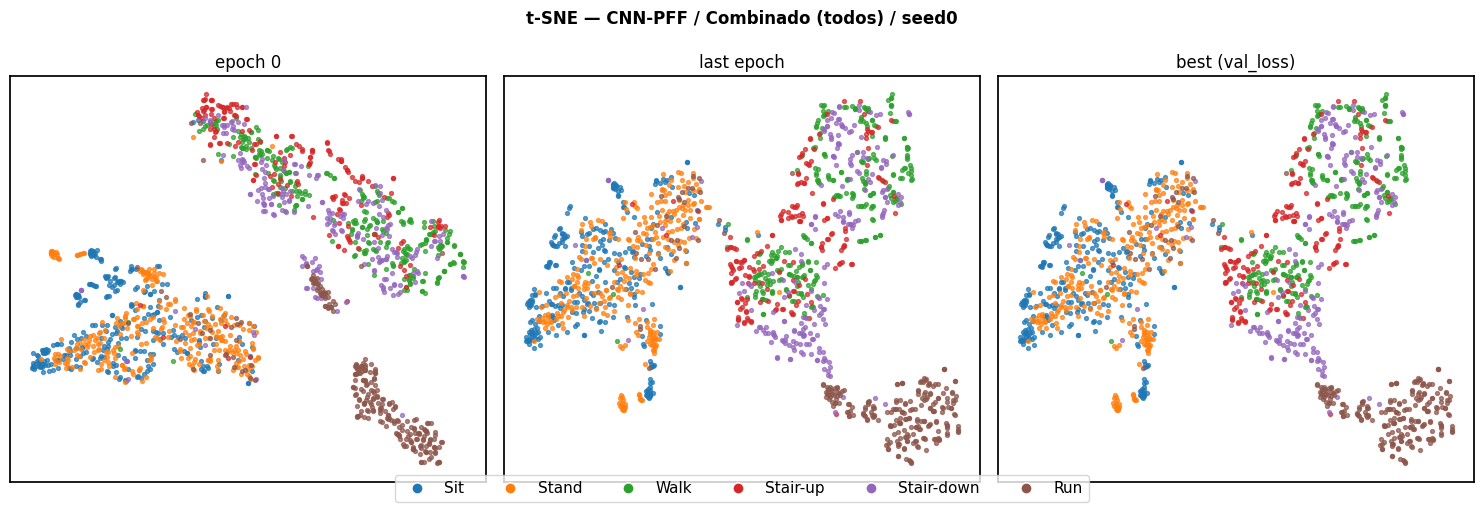

Using DataLoader with shuffle=False


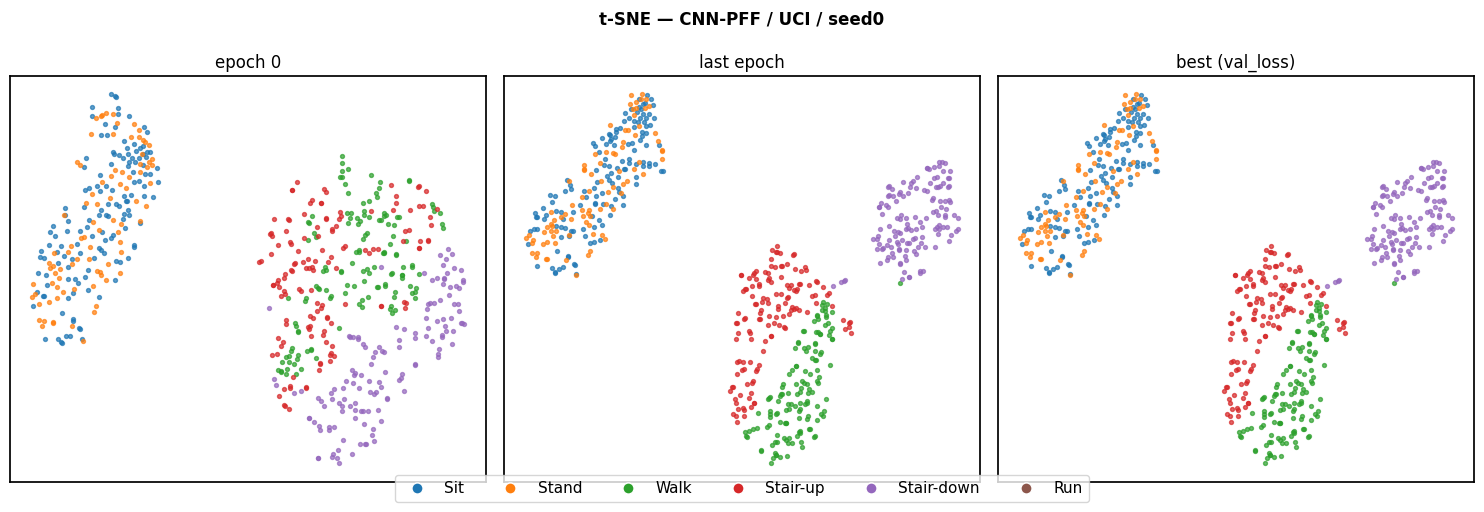

Using DataLoader with shuffle=False


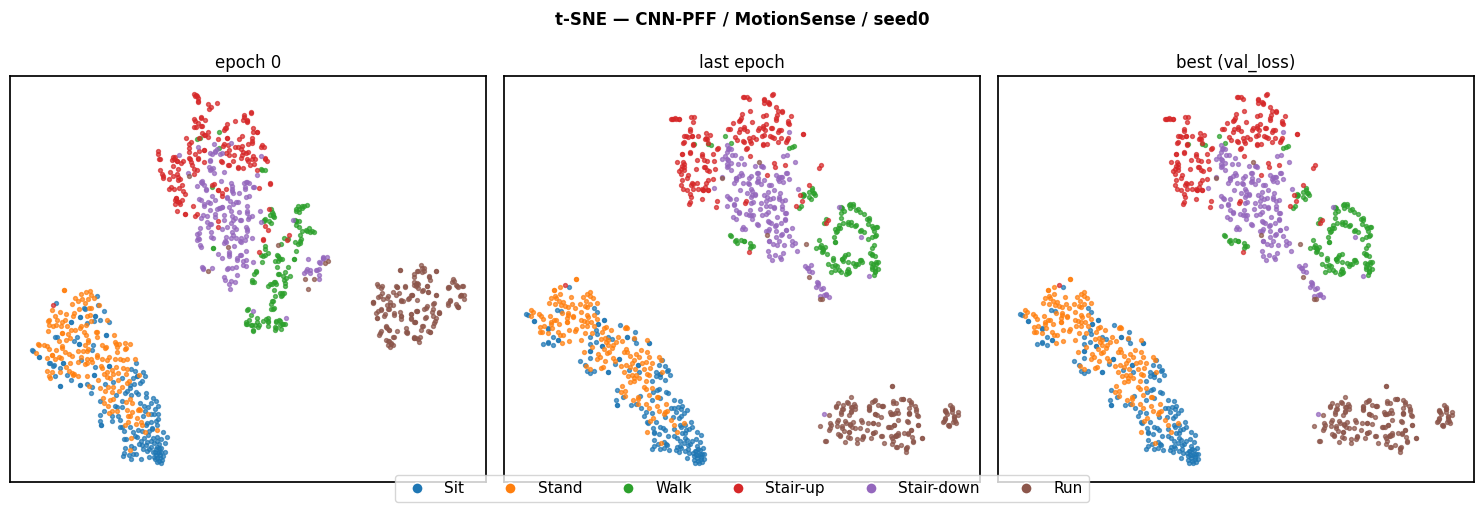

Using DataLoader with shuffle=False


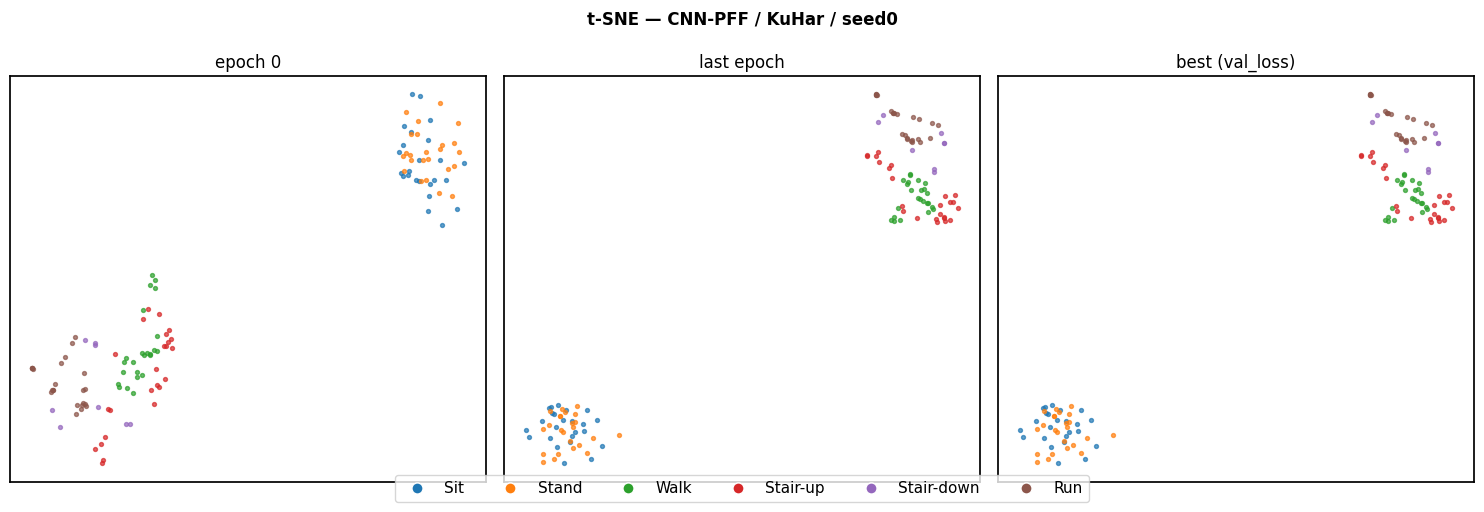

Using DataLoader with shuffle=False


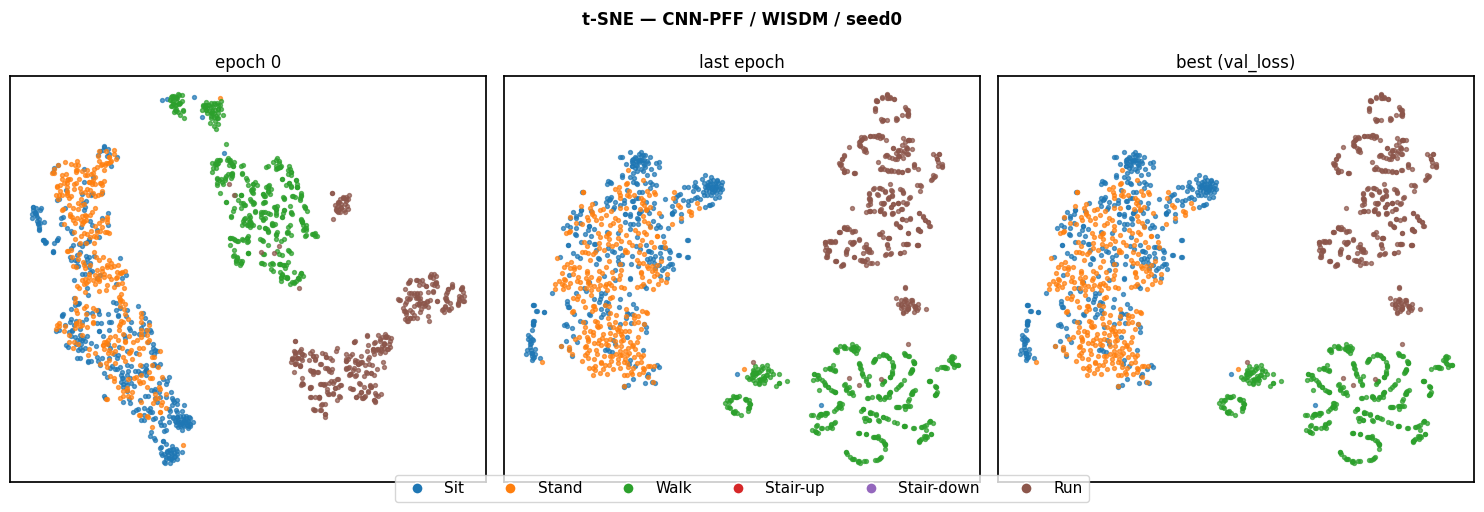

Using DataLoader with shuffle=False


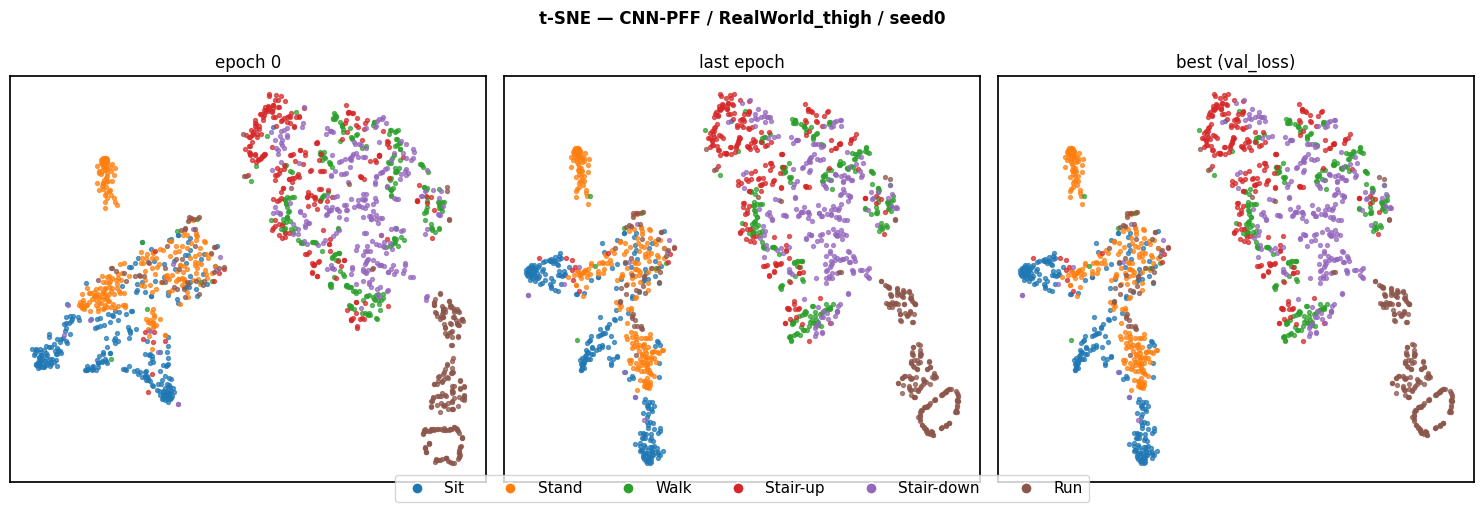

Using DataLoader with shuffle=False


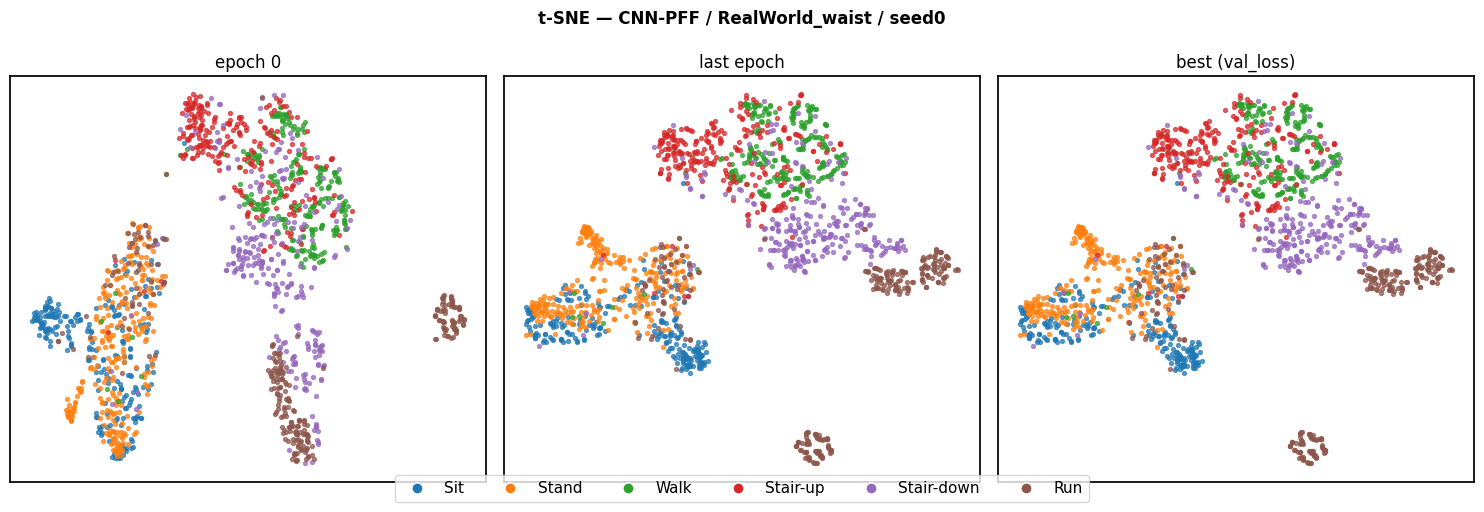

Using DataLoader with shuffle=False


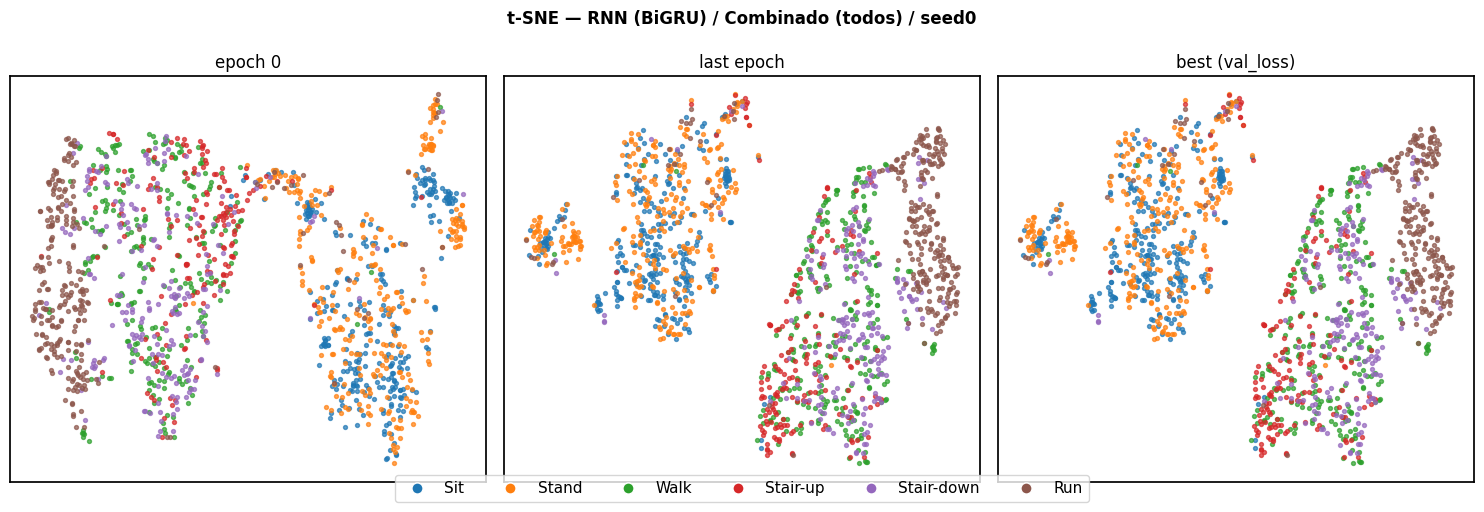

Using DataLoader with shuffle=False


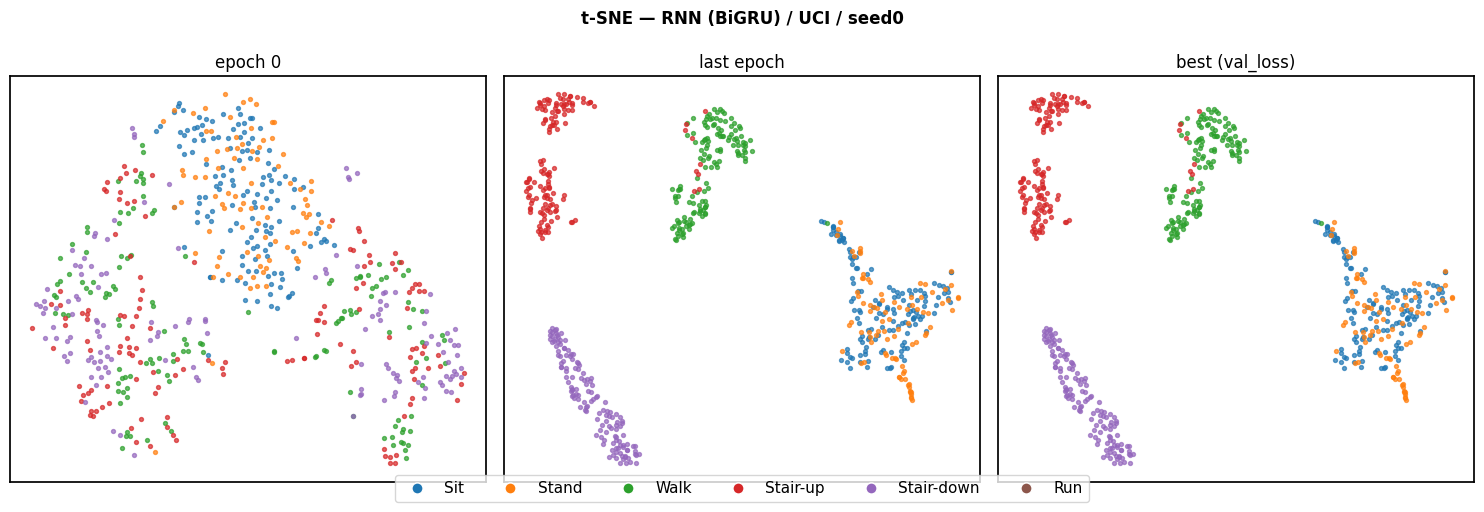

Using DataLoader with shuffle=False


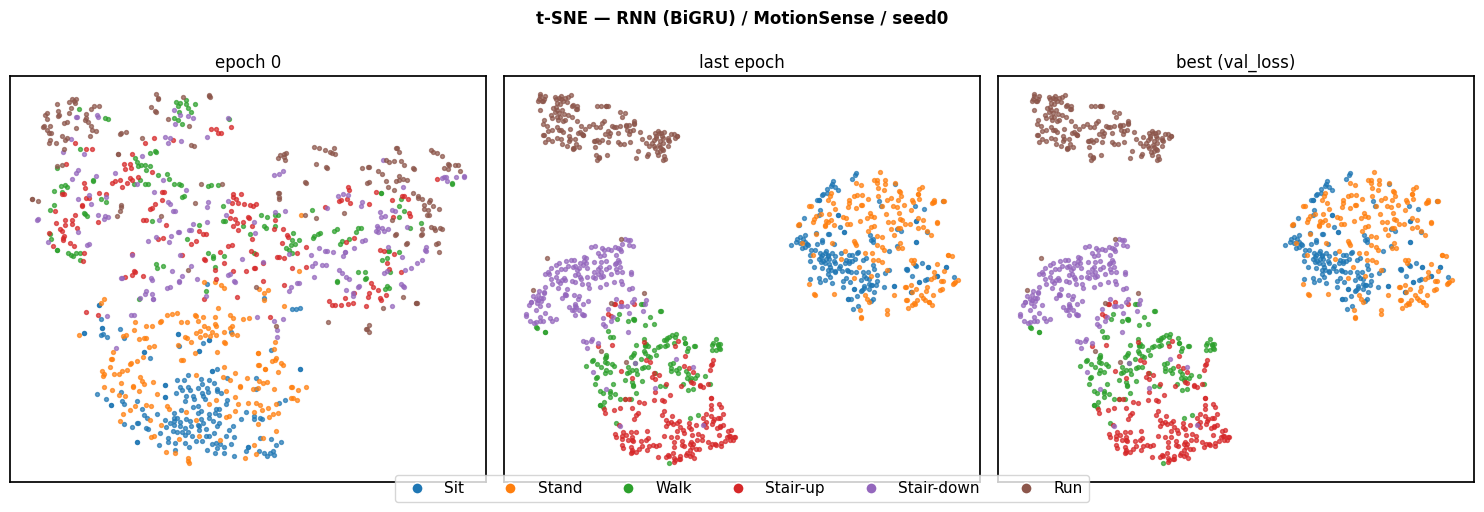

Using DataLoader with shuffle=False


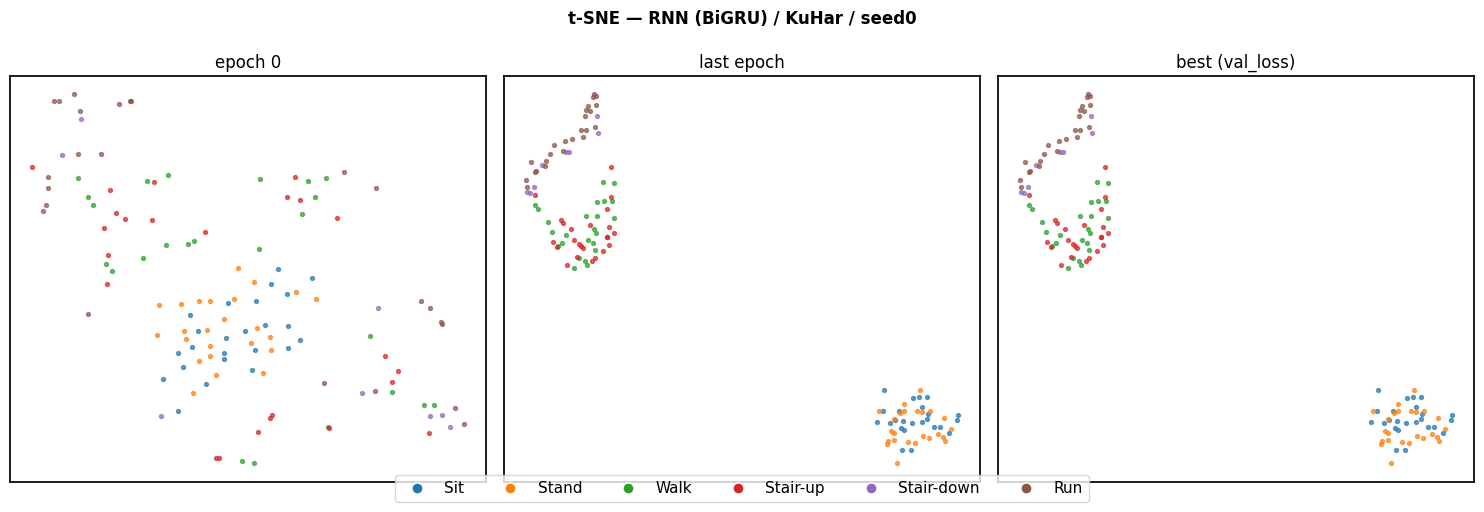

Using DataLoader with shuffle=False


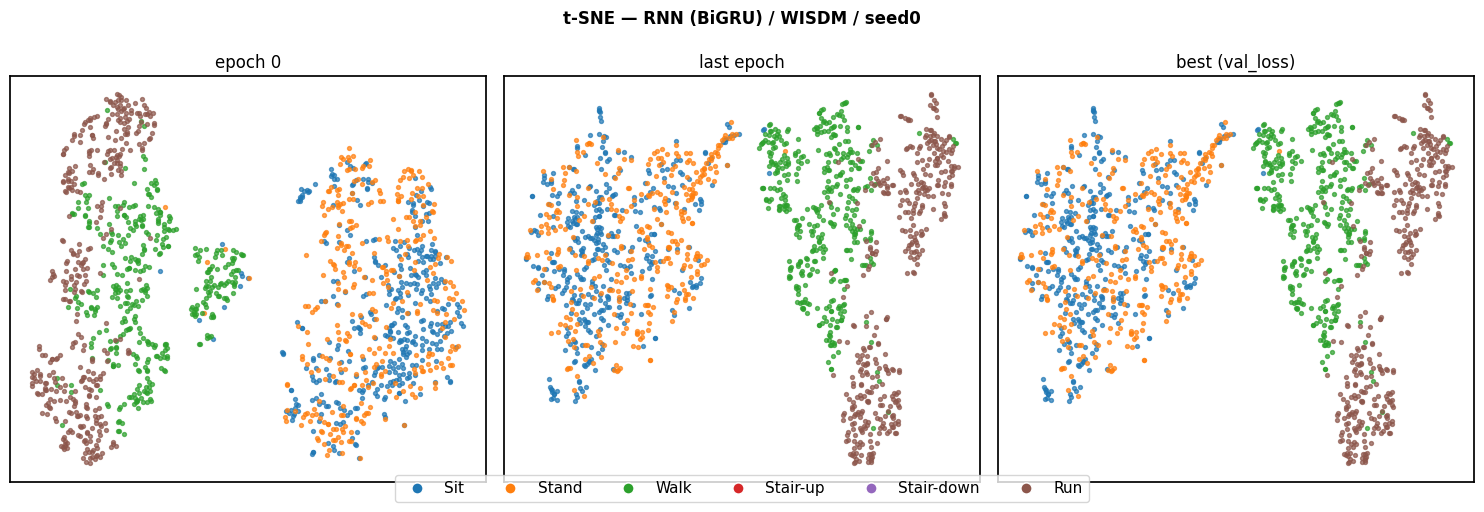

Using DataLoader with shuffle=False


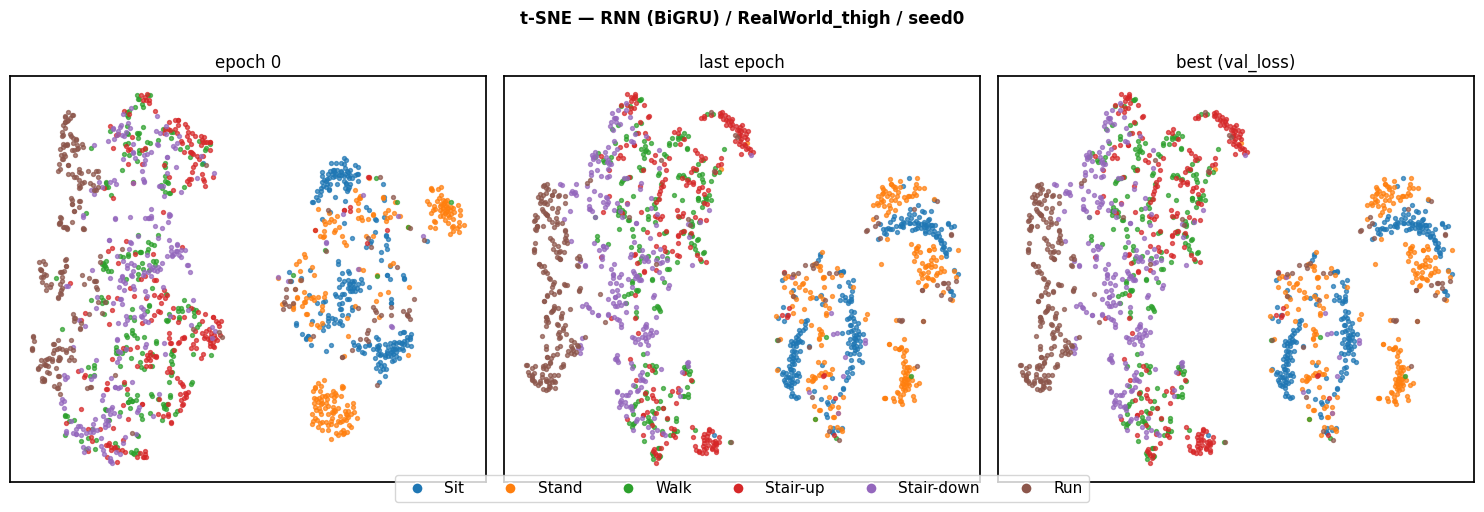

Using DataLoader with shuffle=False


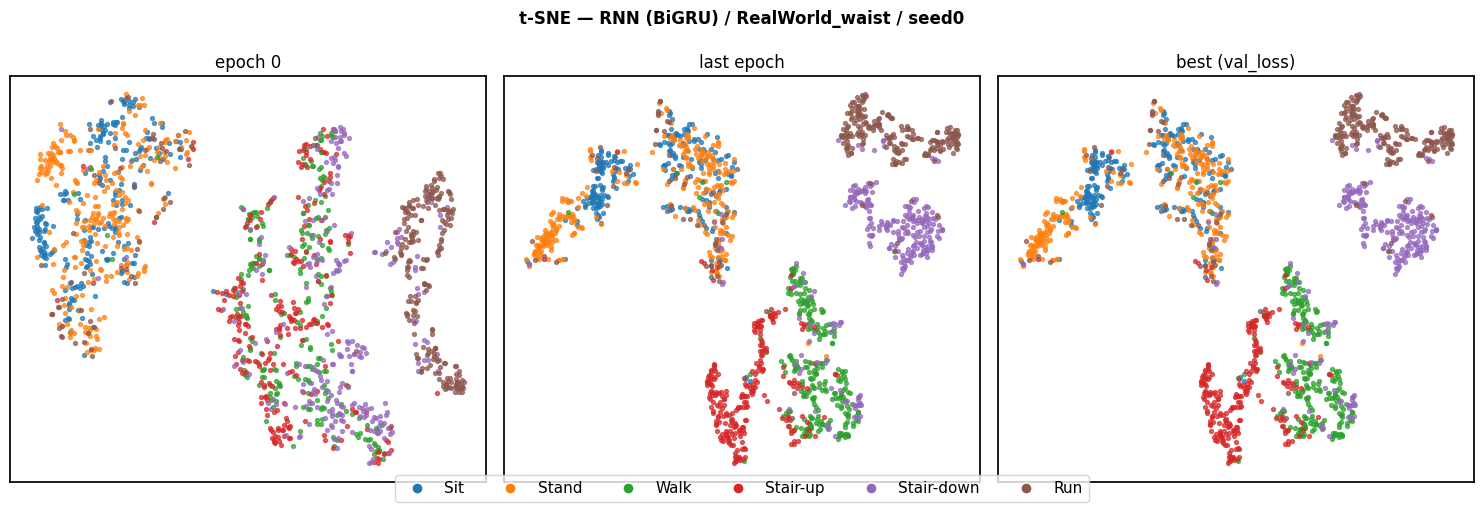

In [12]:
def plot_encoder_tsne(seed: int = 0, max_samples: int = 1500):
    palette = sns.color_palette("tab10", n_colors=NUM_CLASSES)
    kind_labels = {"first": "epoch 0", "last": "last epoch", "best": "best (val_loss)"}
    # Combinado primeiro, depois os 6 datasets individuais.
    for encoder in ENCODERS:
        for dataset in [COMBINED] + DATASETS:
            ds_label = COMBINED_PRETTY if dataset == COMBINED else dataset
            ckpts = {k: safe_ckpt_path(encoder, dataset, seed, k) for k in ("first", "last", "best")}
            if not any(ckpts.values()):
                continue
            try:
                loader = get_test_loader(dataset)
            except Exception as e:
                print(f"[SKIP] loader {dataset}: {e}")
                continue
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            fig.suptitle(
                f"t-SNE — {ENCODER_PRETTY[encoder]} / {ds_label} / seed{seed}",
                fontsize=12,
                fontweight="bold",
            )
            last_handles = None
            for ax, kind in zip(axes, ["first", "last", "best"]):
                ax.set_title(kind_labels[kind])
                ax.set_xticks([])
                ax.set_yticks([])
                ckpt = ckpts[kind]
                if ckpt is None:
                    ax.text(0.5, 0.5, "ckpt ausente", ha="center", va="center", transform=ax.transAxes, color="gray")
                    continue
                try:
                    model = load_checkpoint(encoder, ckpt)
                    feats, labels = extract_features_and_labels(model, loader)
                    if feats.shape[0] == 0:
                        ax.text(0.5, 0.5, "sem dados", ha="center", va="center", transform=ax.transAxes, color="gray")
                        del model
                        free_gpu()
                        continue
                    emb, idx = tsne_2d(feats, max_samples=max_samples)
                    lab_sub = labels[idx]
                    handles_local = []
                    for c in range(NUM_CLASSES):
                        sel = lab_sub == c
                        if sel.any():
                            sc = ax.scatter(emb[sel, 0], emb[sel, 1], s=8, alpha=0.7, color=palette[c], label=ACTIVITY_LABELS[c])
                            handles_local.append(sc)
                    last_handles = handles_local if handles_local else last_handles
                    del model
                    free_gpu()
                except Exception as e:
                    ax.text(0.5, 0.5, f"erro: {e}", ha="center", va="center", transform=ax.transAxes, fontsize=7, wrap=True)
            if last_handles:
                fig.legend(
                    handles=[plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[c], markersize=8, label=ACTIVITY_LABELS[c]) for c in range(NUM_CLASSES)],
                    loc="lower center",
                    ncol=NUM_CLASSES,
                    bbox_to_anchor=(0.5, -0.02),
                )
            plt.tight_layout()
            plt.show()


plot_encoder_tsne(seed=0)

## 6. t-SNE de transfer learning — matriz 7×6 (best.ckpt, seed 0)

Para cada encoder: para cada par `(source, target)`, carrega `best.ckpt` treinado em `source` (seed 0) e plota t-SNE dos embeddings do test set de `target`, colorido pela atividade real. A **primeira linha** é o modelo combinado (treinado em todos); a diagonal das demais linhas = in-distribution.

Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffl

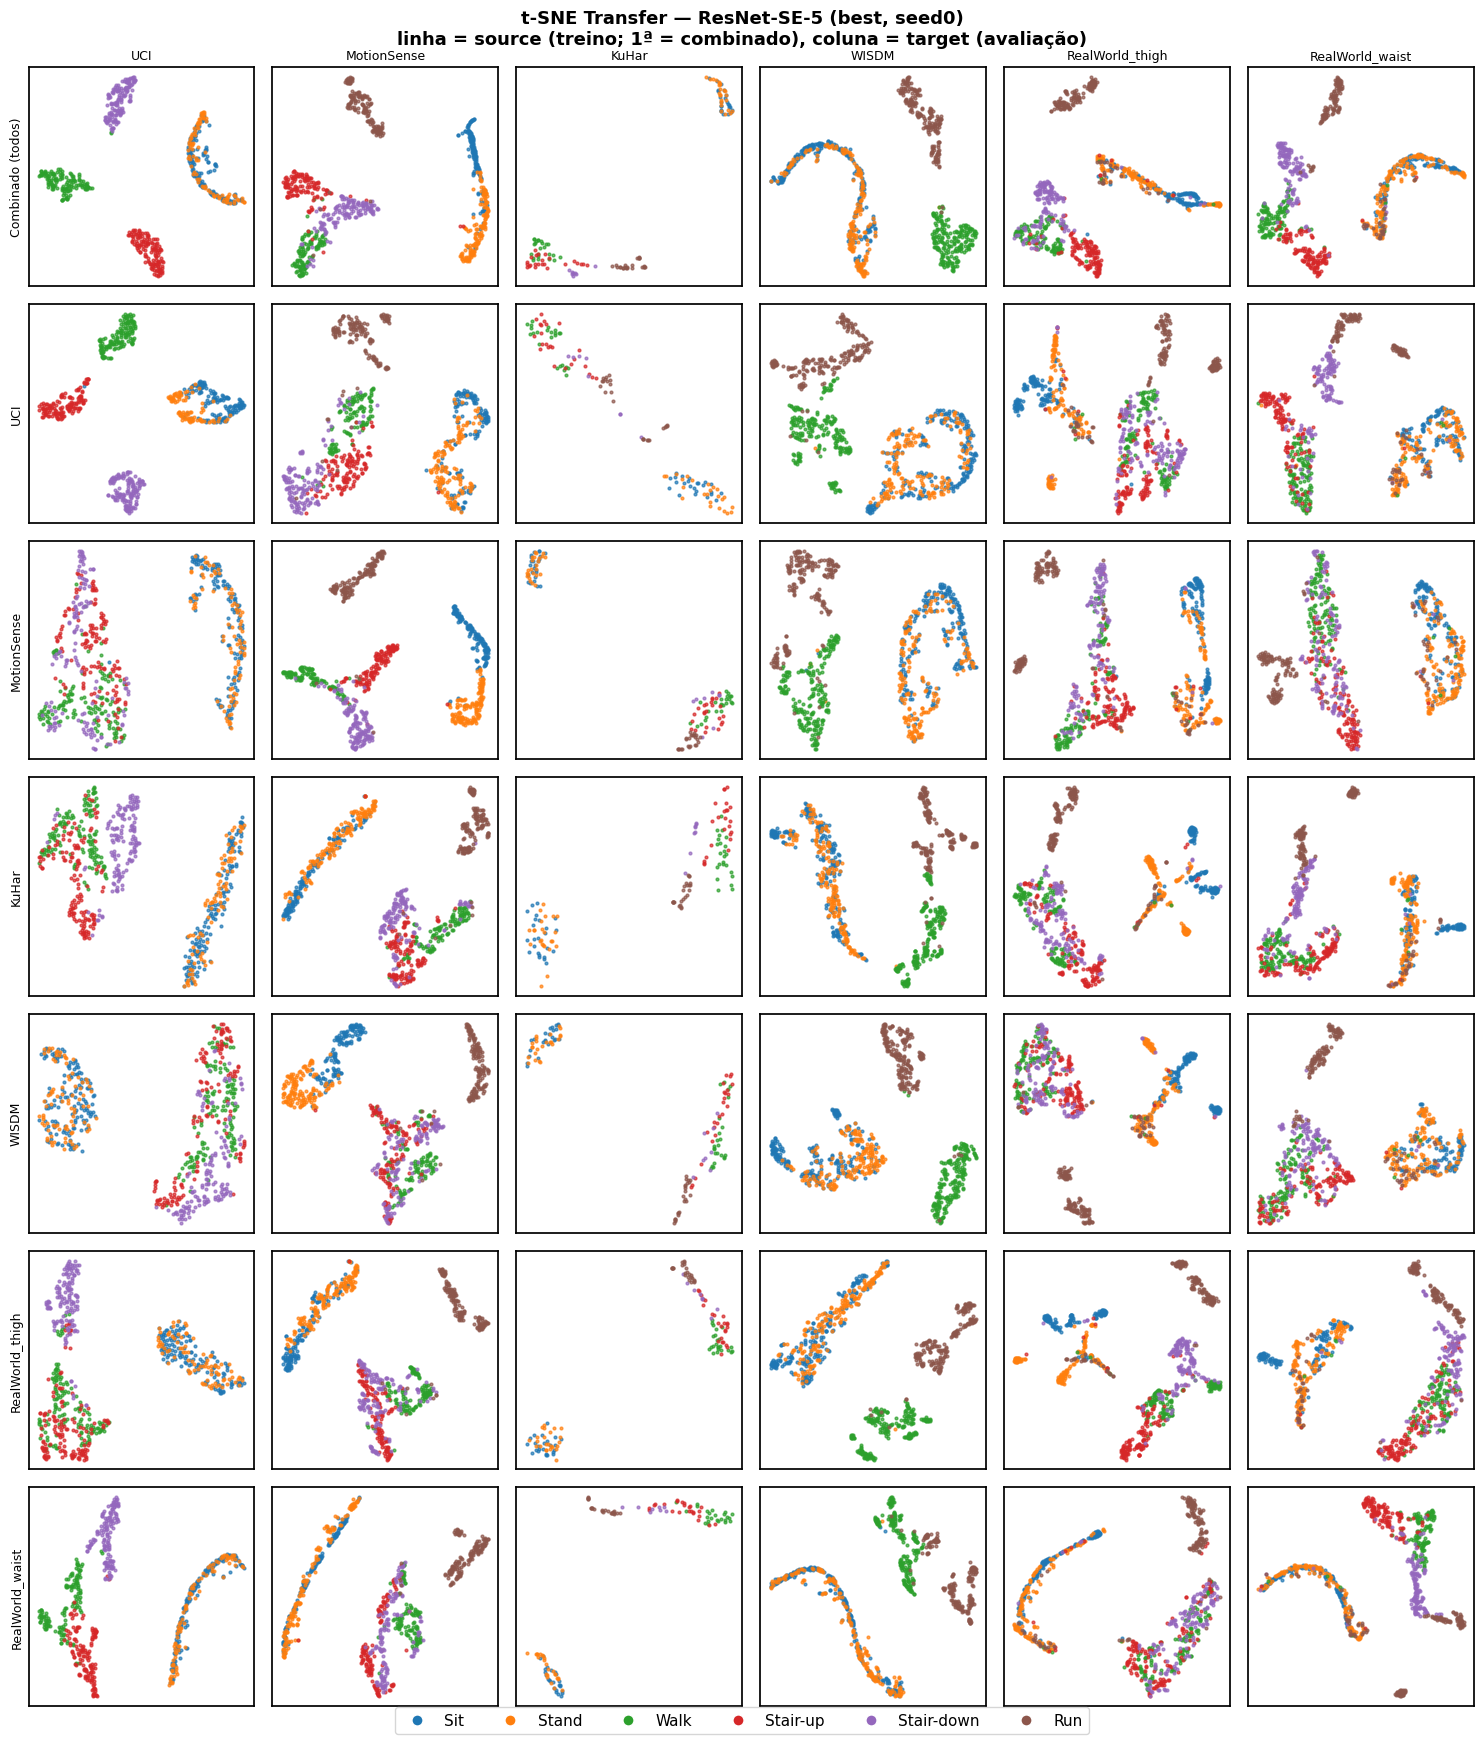

Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffl

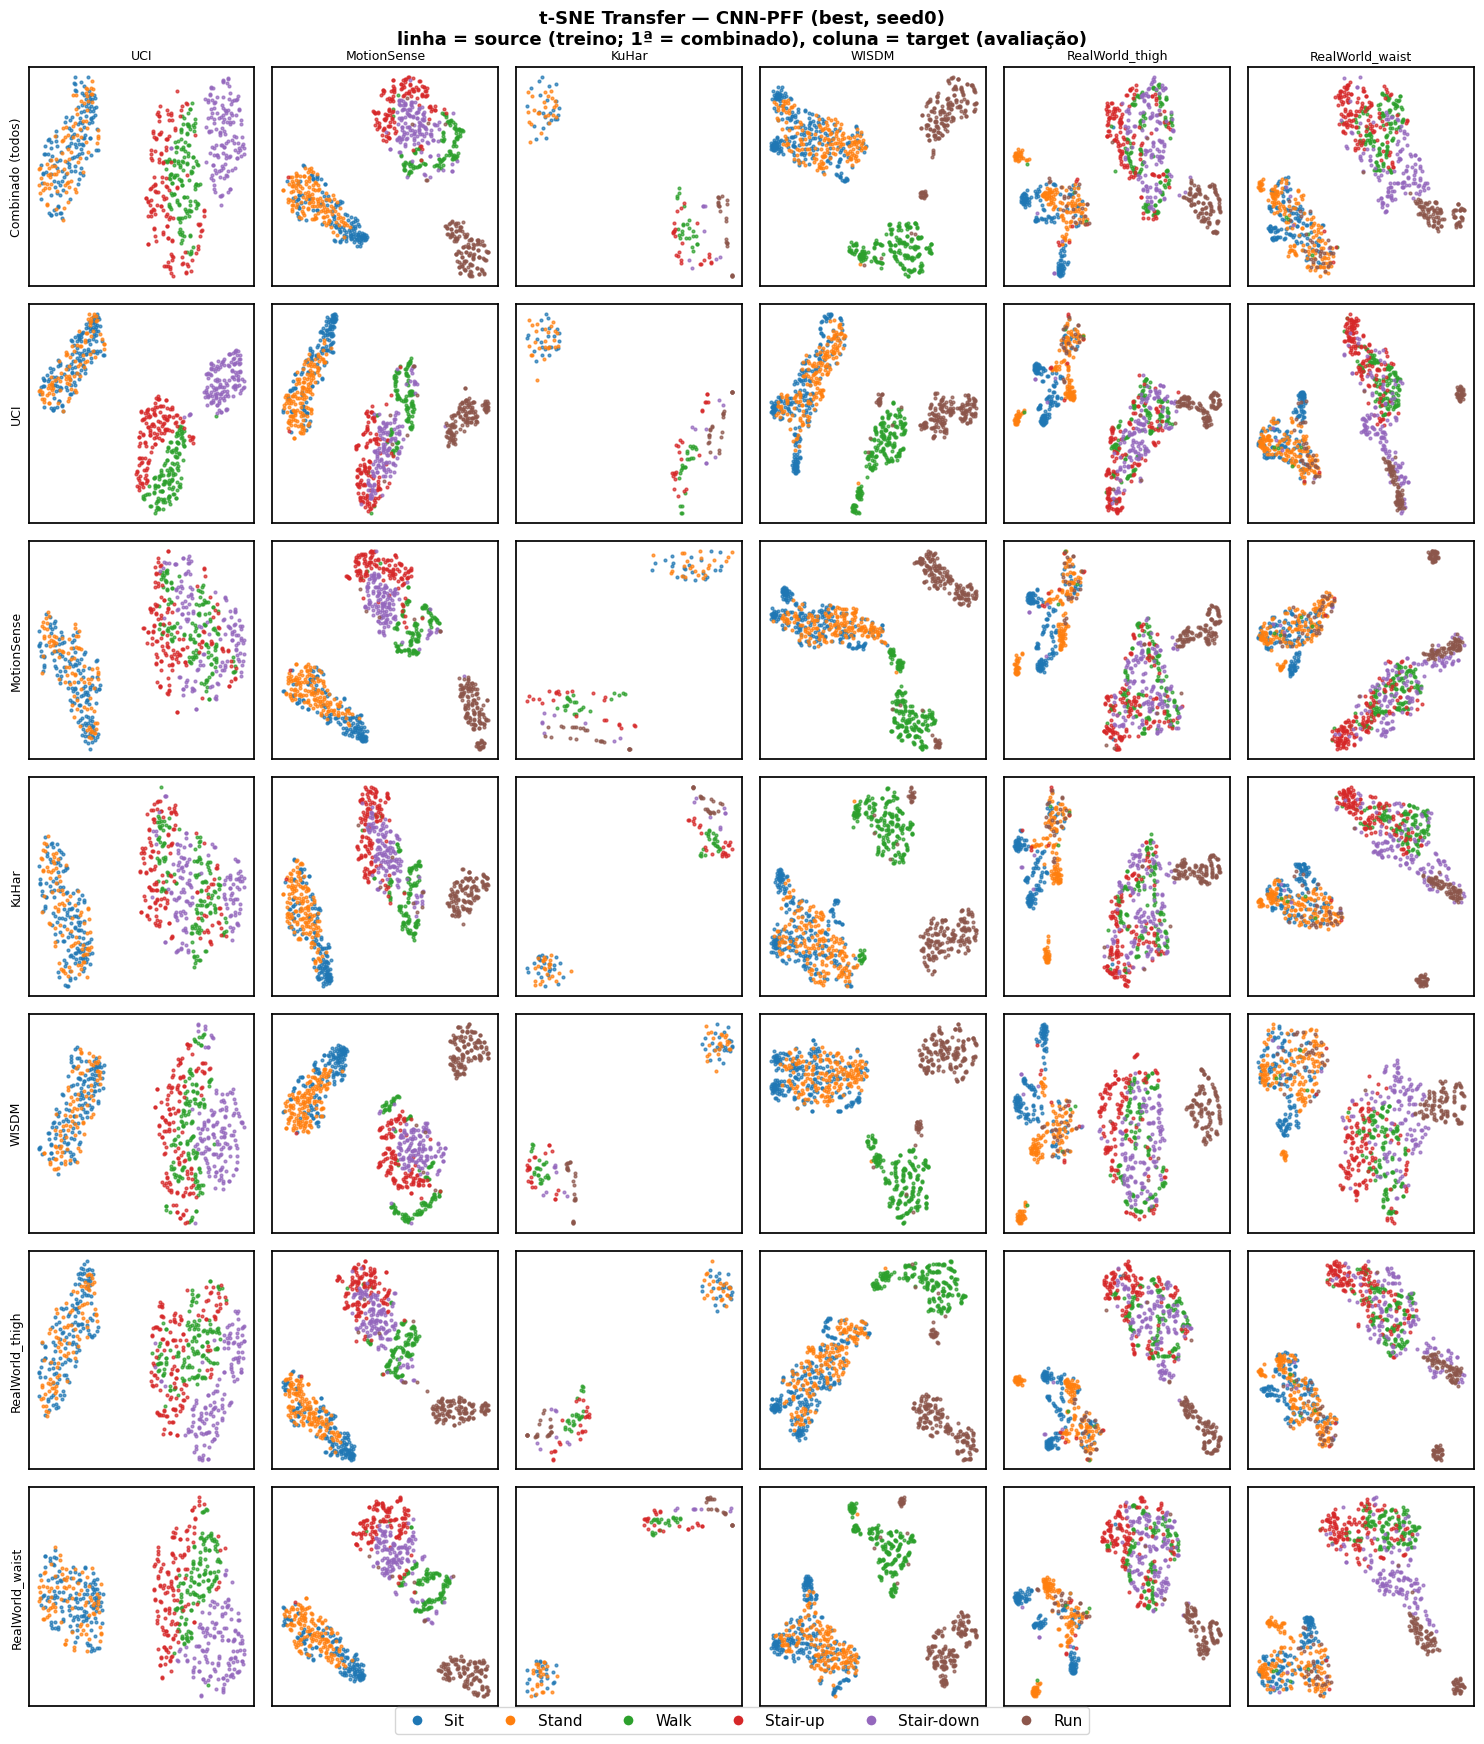

Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffle=False
Using DataLoader with shuffl

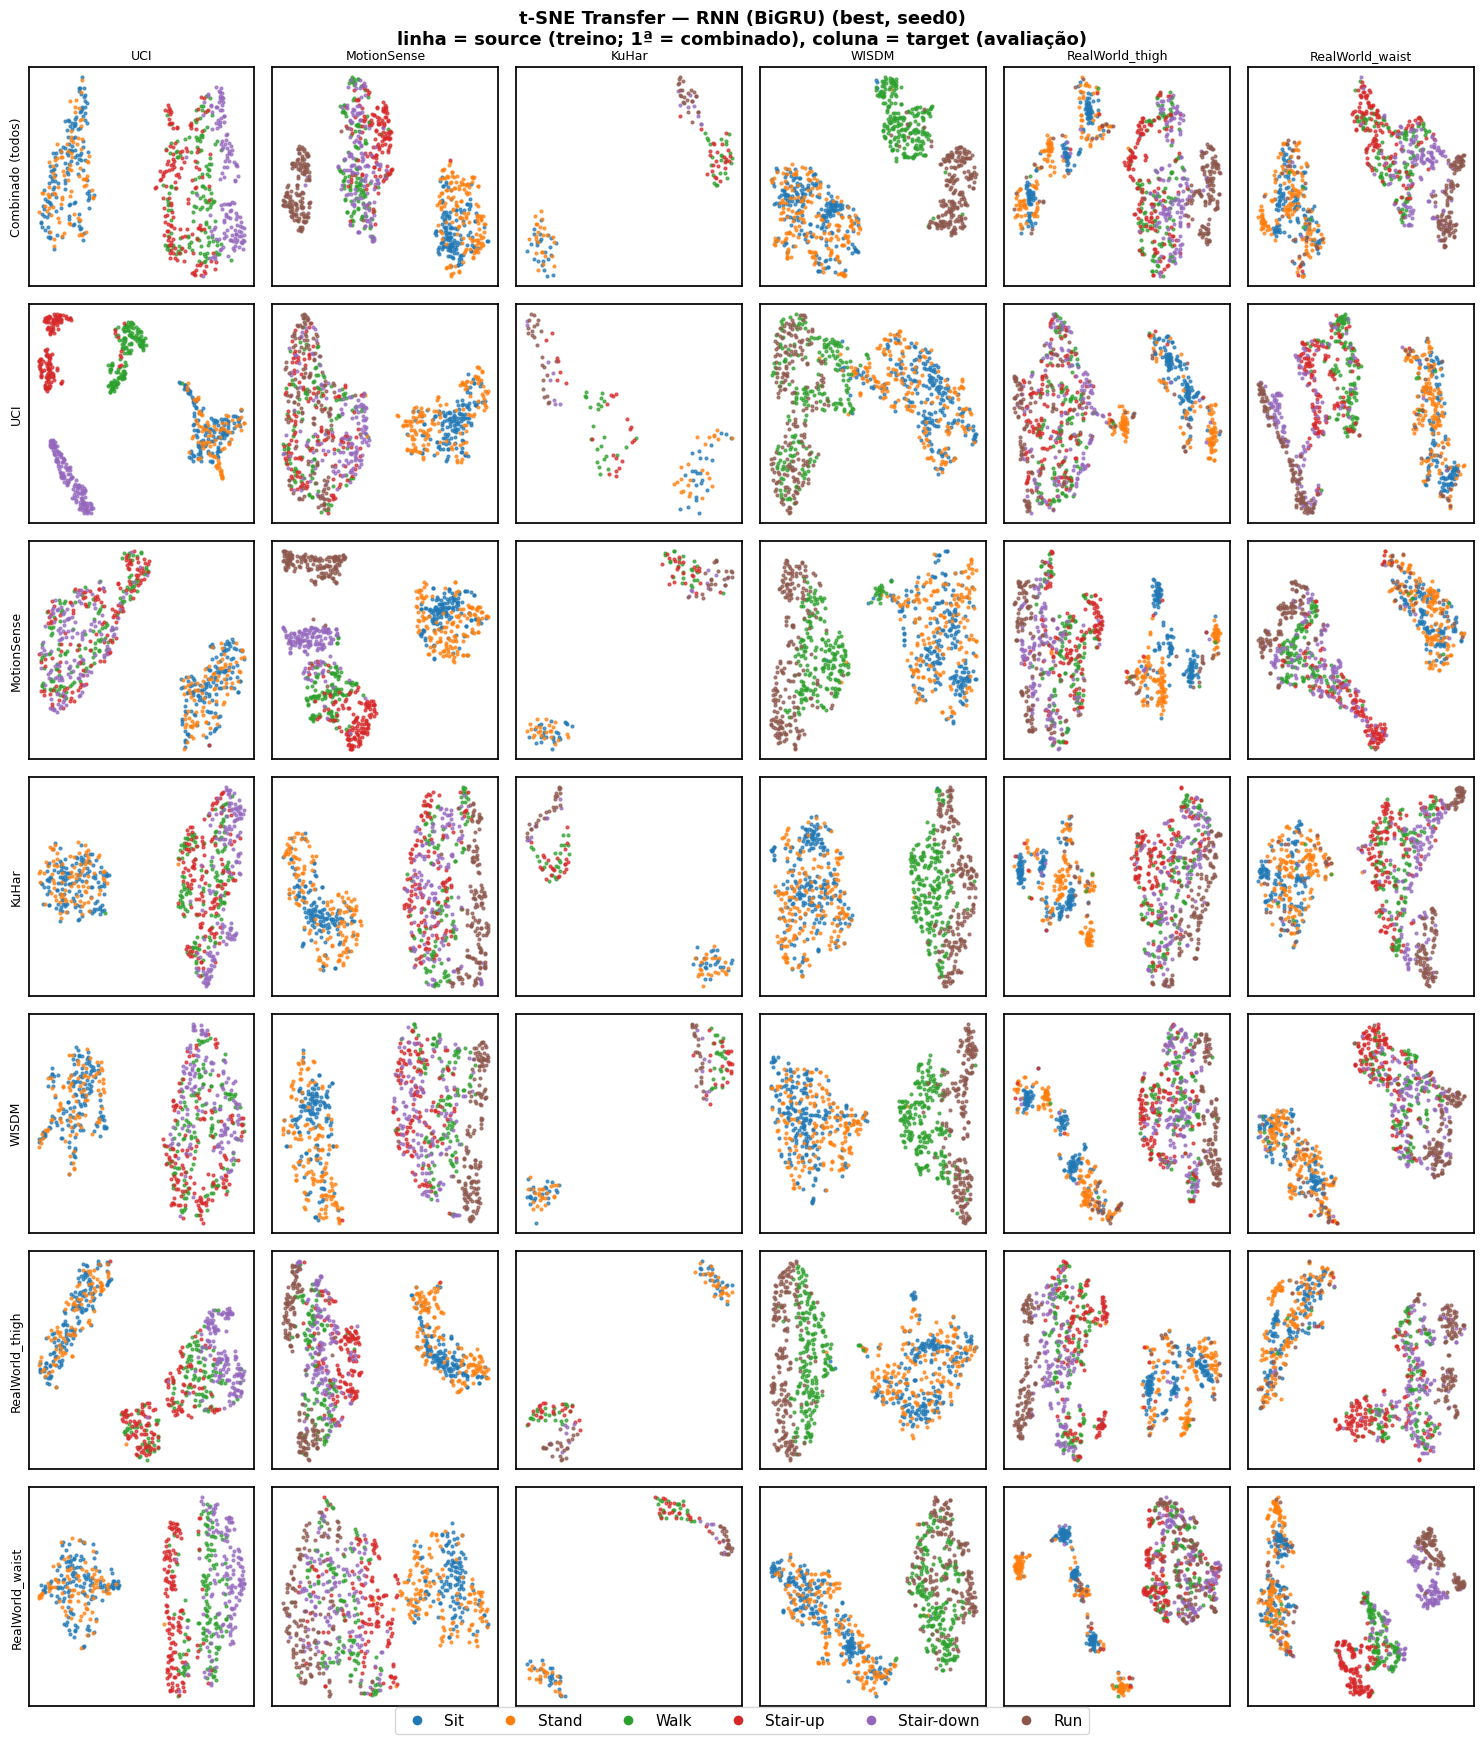

In [13]:
def plot_transfer_tsne(seed: int = 0, max_samples: int = 800):
    palette = sns.color_palette("tab10", n_colors=NUM_CLASSES)
    # Linhas = fontes (combinado primeiro + 6 datasets); colunas = 6 alvos reais.
    sources = [COMBINED] + DATASETS
    nrow, ncol = len(sources), len(DATASETS)
    for encoder in ENCODERS:
        fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.5 * nrow))
        fig.suptitle(
            f"t-SNE Transfer — {ENCODER_PRETTY[encoder]} (best, seed{seed})\nlinha = source (treino; 1ª = combinado), coluna = target (avaliação)",
            fontsize=13,
            fontweight="bold",
        )
        for i, source in enumerate(sources):
            src_label = COMBINED_PRETTY if source == COMBINED else source
            ckpt = safe_ckpt_path(encoder, source, seed, "best")
            model = None
            if ckpt is not None:
                try:
                    model = load_checkpoint(encoder, ckpt)
                except Exception as e:
                    print(f"[SKIP] load {encoder}/{source}/seed{seed}: {e}")
            for j, target in enumerate(DATASETS):
                ax = axes[i, j]
                ax.set_xticks([])
                ax.set_yticks([])
                if i == 0:
                    ax.set_title(target, fontsize=9)
                if j == 0:
                    ax.set_ylabel(src_label, fontsize=9)
                if model is None:
                    ax.text(0.5, 0.5, "sem ckpt", ha="center", va="center", transform=ax.transAxes, color="gray", fontsize=8)
                    continue
                try:
                    loader = get_test_loader(target)
                    feats, labels = extract_features_and_labels(model, loader)
                    if feats.shape[0] == 0:
                        ax.text(0.5, 0.5, "sem dados", ha="center", va="center", transform=ax.transAxes, color="gray", fontsize=8)
                        continue
                    emb, idx = tsne_2d(feats, max_samples=max_samples)
                    lab_sub = labels[idx]
                    for c in range(NUM_CLASSES):
                        sel = lab_sub == c
                        if sel.any():
                            ax.scatter(emb[sel, 0], emb[sel, 1], s=4, alpha=0.7, color=palette[c])
                except Exception as e:
                    ax.text(0.5, 0.5, "erro", ha="center", va="center", transform=ax.transAxes, color="red", fontsize=8)
            if model is not None:
                del model
                free_gpu()
        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[c], markersize=8, label=ACTIVITY_LABELS[c])
            for c in range(NUM_CLASSES)
        ]
        fig.legend(handles=handles, loc="lower center", ncol=NUM_CLASSES, bbox_to_anchor=(0.5, -0.01))
        plt.tight_layout()
        plt.show()


plot_transfer_tsne(seed=0)